## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import pyarrow.parquet as pq

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Dataset Paths and Sampling Settings

In [2]:
DATASETS = {
    "FHV": Path("../data/raw/fhv"),
    "FHVHV": Path("../data/raw/fhvhv"),
    "Green": Path("../data/raw/green"),
    "Yellow": Path("../data/raw/yellow"),
}

SAMPLE_ROWS_PER_DATASET = 250_000
RANDOM_STATE = 42

for name, path in DATASETS.items():
    files = sorted(path.glob("*.parquet"))
    print(f"{name:8} | {len(files):4} files | {path}")

FHV      |   21 files | ..\data\raw\fhv
FHVHV    |   21 files | ..\data\raw\fhvhv
Green    |   21 files | ..\data\raw\green
Yellow   |   21 files | ..\data\raw\yellow


## 3. Representative Sampling

In [3]:
SAMPLE_CONFIG = {
    "FHV": 13_800_000,
    "FHVHV": 4_400_000,
    "Green": 6_000_000,
    "Yellow": 6_350_000,
}

RANDOM_STATE = 42

def sample_parquet_folder(folder, n_rows, random_state=42):
    rng = np.random.default_rng(random_state)
    files = sorted(Path(folder).glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files found in {folder}")

    row_groups = []
    for file in files:
        pf = pq.ParquetFile(file)
        for rg in range(pf.num_row_groups):
            rows = pf.metadata.row_group(rg).num_rows
            row_groups.append((file, rg, rows))

    if not row_groups:
        return pd.DataFrame()

    total_available_rows = sum(rg[2] for rg in row_groups)
    target_rows = min(n_rows, total_available_rows)

    order = rng.permutation(len(row_groups))
    pieces = []
    total = 0

    for idx in order:
        file, rg, rows = row_groups[idx]
        pf = pq.ParquetFile(file)
        piece = pf.read_row_group(rg).to_pandas()

        remaining = target_rows - total
        if len(piece) > remaining:
            piece = piece.sample(n=remaining, random_state=random_state)

        pieces.append(piece)
        total += len(piece)
        if total >= target_rows:
            break

    if not pieces:
        return pd.DataFrame()

    return pd.concat(pieces, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)

samples = {}
for name, path in DATASETS.items():
    n_rows = SAMPLE_CONFIG[name]
    print(f"Sampling {name} ({n_rows:,} rows)...")
    samples[name] = sample_parquet_folder(path, n_rows=n_rows, random_state=RANDOM_STATE)
    
    # Calculate actual memory usage
    mem_mb = samples[name].memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"  Shape: {samples[name].shape} | Memory: {mem_mb:.2f} MB")

Sampling FHV (13,800,000 rows)...
  Shape: (13800000, 7) | Memory: 895.80 MB
Sampling FHVHV (4,400,000 rows)...
  Shape: (4400000, 25) | Memory: 899.25 MB
Sampling Green (6,000,000 rows)...
  Shape: (1067809, 21) | Memory: 159.94 MB
Sampling Yellow (6,350,000 rows)...
  Shape: (6350000, 20) | Memory: 901.71 MB


## 4. First Look at the Data

In [4]:
for name, df in samples.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", df.shape)
    display(df.head())


FHV
Shape: (13800000, 7)


,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag,Affiliated_base_number
0,B03524,2025-04-11 10:35:01,2025-04-11 11:05:56,NaN,NaN,NaN,B03404
1,B00449,2025-04-03 09:58:17,2025-04-03 10:20:02,165.0,55.0,NaN,B00449
2,B03524,2025-03-07 19:33:15,2025-03-07 20:02:19,NaN,NaN,NaN,B03404
3,B00412,2025-09-15 13:17:16,2025-09-15 13:41:05,NaN,NaN,NaN,B03404
4,B01667,2025-07-01 06:54:32,2025-07-01 07:10:56,NaN,138.0,NaN,B03404



FHVHV
Shape: (4400000, 25)


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-17 08:41:59,2026-01-17 08:43:31,2026-01-17 08:43:50,2026-01-17 08:48:43,179,7,1.10,...,0.00,0.0,0.00,4.93,N,N,N,N,N,0.0
1,HV0005,B03406,NaN,2025-11-07 12:43:17,2025-11-07 12:45:08,2025-11-07 12:46:08,2025-11-07 13:03:12,181,33,1.78,...,0.00,0.0,3.01,14.14,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2025-11-08 01:49:46,2025-11-08 01:52:03,2025-11-08 01:52:13,2025-11-08 01:59:15,137,140,2.15,...,2.75,0.0,0.00,7.30,N,N,N,N,N,1.5
3,HV0003,B03404,B03404,2025-01-30 21:51:54,2025-01-30 21:53:04,2025-01-30 21:53:58,2025-01-30 22:10:18,112,66,5.14,...,0.00,0.0,3.64,16.51,N,N,N,N,N,0.0
4,HV0003,B03404,B03404,2026-01-17 14:16:04,2026-01-17 14:20:20,2026-01-17 14:21:30,2026-01-17 15:11:07,80,132,15.91,...,0.00,2.5,0.00,54.64,N,N,N,N,N,0.0



Green
Shape: (1067809, 21)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2024-09-27 04:15:22,2024-09-27 04:16:00,N,1.0,116,116,1.0,0.00,3.0,...,0.5,55.00,0.0,NaN,1.0,60.50,1.0,1.0,0.00,NaN
1,2,2025-04-27 19:41:23,2025-04-27 19:49:09,N,1.0,130,215,1.0,1.74,10.7,...,0.5,3.66,0.0,NaN,1.0,15.86,1.0,1.0,0.00,0.0
2,2,2026-01-26 10:18:35,2026-01-26 10:20:46,N,5.0,74,74,2.0,0.20,14.0,...,0.0,1.00,0.0,NaN,1.0,16.00,1.0,2.0,0.00,0.0
3,2,2024-07-27 16:02:47,2024-07-27 16:08:18,N,1.0,43,263,1.0,1.02,7.2,...,0.5,2.29,0.0,NaN,1.0,13.74,1.0,1.0,2.75,NaN
4,2,2025-06-01 22:00:07,2025-06-01 22:10:31,N,1.0,74,141,1.0,3.39,15.6,...,0.5,4.17,0.0,NaN,1.0,25.02,1.0,1.0,2.75,0.0



Yellow
Shape: (6350000, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-12-18 06:37:48,2025-12-18 06:49:07,NaN,2.38,NaN,NaN,236,230,0,30.81,0.0,0.5,0.00,0.0,1.0,35.56,NaN,NaN,0.75
1,1,2024-05-28 23:46:21,2024-05-28 23:54:42,1.0,1.50,1.0,N,239,236,1,10.70,3.5,0.5,1.00,0.0,1.0,16.70,2.5,0.0,NaN
2,2,2024-05-20 12:43:57,2024-05-20 12:54:22,1.0,1.98,1.0,N,186,211,1,12.10,0.0,0.5,3.22,0.0,1.0,19.32,2.5,0.0,NaN
3,2,2024-05-23 06:35:30,2024-05-23 06:41:55,1.0,1.05,1.0,N,161,68,2,8.60,0.0,0.5,0.00,0.0,1.0,15.10,2.5,0.0,NaN
4,2,2024-12-27 16:23:30,2024-12-27 16:32:17,1.0,1.43,1.0,N,186,113,1,10.00,2.5,0.5,3.30,0.0,1.0,19.80,2.5,0.0,NaN


In [5]:
for name, df in samples.items():
    print("\n" + "=" * 80)
    print(name, "— INFO")
    print("=" * 80)
    df.info()


FHV — INFO
<class 'pandas.DataFrame'>
RangeIndex: 13800000 entries, 0 to 13799999
Data columns (total 7 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   dispatching_base_num    str           
 1   pickup_datetime         datetime64[us]
 2   dropOff_datetime        datetime64[us]
 3   PUlocationID            float64       
 4   DOlocationID            float64       
 5   SR_Flag                 float64       
 6   Affiliated_base_number  str           
dtypes: datetime64[us](2), float64(3), str(2)
memory usage: 895.8 MB

FHVHV — INFO
<class 'pandas.DataFrame'>
RangeIndex: 4400000 entries, 0 to 4399999
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     str           
 1   dispatching_base_num  str           
 2   originating_base_num  str           
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   picku

In [6]:
for name, df in samples.items():
    print("\n" + "=" * 80)
    print(name, "— COLUMNS")
    print("=" * 80)
    print(df.columns.tolist())


FHV — COLUMNS
['dispatching_base_num', 'pickup_datetime', 'dropOff_datetime', 'PUlocationID', 'DOlocationID', 'SR_Flag', 'Affiliated_base_number']

FHVHV — COLUMNS
['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']

Green — COLUMNS
['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']

Yellow — 

In [7]:
for name, df in samples.items():
    print("\n" + "=" * 80)
    print(name, "— NUMERICAL SUMMARY")
    print("=" * 80)
    display(df.describe(include=[np.number]).T)


FHV — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
PUlocationID,2574755.0,134.715996,75.471720,1.0,71.0,136.0,206.0,265.0
DOlocationID,11508650.0,136.573763,78.630769,1.0,69.0,136.0,212.0,265.0
SR_Flag,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



FHVHV — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
PULocationID,4400000.0,138.404930,75.098886,2.00,75.00,140.000,210.000,265.00
DOLocationID,4400000.0,141.948161,78.012571,1.00,76.00,140.000,216.000,265.00
trip_miles,4400000.0,4.922037,5.809059,0.00,1.51,2.909,6.134,264.50
trip_time,4400000.0,1194.197618,888.338395,0.00,593.00,962.000,1524.000,35036.00
base_passenger_fare,4400000.0,26.415701,24.529460,-115.21,12.20,19.020,31.210,1336.27
tolls,4400000.0,1.090399,3.631722,0.00,0.00,0.000,0.000,77.10
bcf,4400000.0,0.678680,0.654273,0.00,0.30,0.480,0.800,39.09
sales_tax,4400000.0,2.187277,1.996243,0.00,1.00,1.600,2.650,80.18
congestion_surcharge,4400000.0,1.005095,1.319928,0.00,0.00,0.000,2.750,2.75
airport_fee,4400000.0,0.207186,0.692766,0.00,0.00,0.000,0.000,7.25



Green — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
VendorID,1067809.0,2.001105,0.759638,1.00,2.0,2.00,2.00,6.00
RatecodeID,998615.0,1.269476,2.131174,1.00,1.0,1.00,1.00,99.00
PULocationID,1067809.0,96.666621,56.606378,1.00,74.0,75.00,97.00,265.00
DOLocationID,1067809.0,142.356294,77.043386,1.00,74.0,140.00,229.00,265.00
passenger_count,998615.0,1.304208,0.959451,0.00,1.0,1.00,1.00,9.00
trip_distance,1067809.0,17.611769,1102.203346,0.00,1.2,1.95,3.44,262315.94
fare_amount,1067809.0,18.360307,17.968732,-470.60,9.3,14.20,20.50,1086.60
extra,1067809.0,0.904685,1.396794,-7.50,0.0,0.00,1.00,12.50
mta_tax,1067809.0,0.575172,0.353587,-0.50,0.5,0.50,0.50,61.50
tip_amount,1067809.0,2.661673,3.603163,-100.00,0.0,2.06,3.92,350.00



Yellow — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
VendorID,6350000.0,1.793111,0.445120,1.00,2.00,2.00,2.00,7.00
passenger_count,4918422.0,1.349335,0.819009,0.00,1.00,1.00,1.00,9.00
trip_distance,6350000.0,6.821362,690.534101,0.00,1.00,1.80,3.51,328827.63
RatecodeID,4918422.0,2.365750,11.111170,1.00,1.00,1.00,1.00,99.00
PULocationID,6350000.0,162.729490,66.103612,1.00,125.00,161.00,233.00,265.00
DOLocationID,6350000.0,161.852343,70.241600,1.00,113.00,162.00,234.00,265.00
payment_type,6350000.0,0.963983,0.738158,0.00,1.00,1.00,1.00,4.00
fare_amount,6350000.0,20.544786,135.212916,-999.00,9.30,14.90,25.40,334076.32
extra,6350000.0,1.160697,1.756679,-9.25,0.00,0.00,2.50,65.99
mta_tax,6350000.0,0.479708,0.130855,-0.50,0.50,0.50,0.50,25.00


## 5. Data Types and Missing Values

In [8]:
for name, df in samples.items():
    print(f"\n{name} data types:")
    display(df.dtypes.to_frame("dtype"))

    missing = df.isnull().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    print(f"{name} missing values:")
    display(missing.to_frame("missing_count"))


FHV data types:


,dtype
dispatching_base_num,str
pickup_datetime,datetime64[us]
dropOff_datetime,datetime64[us]
PUlocationID,float64
DOlocationID,float64
SR_Flag,float64
Affiliated_base_number,str


FHV missing values:


,missing_count
SR_Flag,13800000
PUlocationID,11225245
DOlocationID,2291350
Affiliated_base_number,58925



FHVHV data types:


...

,missing_count
ehail_fee,1067809
cbd_congestion_fee,439986
trip_type,69301
store_and_fwd_flag,69194
RatecodeID,69194
payment_type,69194
congestion_surcharge,69194
passenger_count,69194



Yellow data types:


,dtype
VendorID,int32
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,str
PULocationID,int32
DOLocationID,int32
payment_type,int64


Yellow missing values:


,missing_count
cbd_congestion_fee,4196137
passenger_count,1431578
RatecodeID,1431578
congestion_surcharge,1431578
Airport_fee,1431578
store_and_fwd_flag,1431578


In [9]:
# Missing-value percentages
missing_summary = {}

for name, df in samples.items():
    result = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    }).sort_values("missing_percent", ascending=False)
    missing_summary[name] = result
    print(f"\n{name}")
    display(result[result["missing_count"] > 0].head(20))


FHV


,missing_count,missing_percent
SR_Flag,13800000,100.000000
PUlocationID,11225245,81.342355
DOlocationID,2291350,16.603986
Affiliated_base_number,58925,0.426993



FHVHV


,missing_count,missing_percent
originating_base_num,1243842,28.269136
on_scene_datetime,334041,7.591841
cbd_congestion_fee,308566,7.012864



Green


,missing_count,missing_percent
ehail_fee,1067809,100.000000
cbd_congestion_fee,439986,41.204560
trip_type,69301,6.490018
store_and_fwd_flag,69194,6.479998
RatecodeID,69194,6.479998
payment_type,69194,6.479998
congestion_surcharge,69194,6.479998
passenger_count,69194,6.479998



Yellow


,missing_count,missing_percent
cbd_congestion_fee,4196137,66.080898
passenger_count,1431578,22.544535
RatecodeID,1431578,22.544535
congestion_surcharge,1431578,22.544535
Airport_fee,1431578,22.544535
store_and_fwd_flag,1431578,22.544535


## 6. Duplicate Rows

A full duplicate scan over every taxi row is deliberately **not** performed here because it is one of the most expensive operations on these datasets. We use the representative samples for the standard `duplicated()` check.

In [10]:
for name, df in samples.items():
    duplicate_count = df.duplicated().sum()
    duplicate_percent = duplicate_count / len(df) * 100 if len(df) else 0
    print(f"{name}: {duplicate_count:,} duplicate rows in sample ({duplicate_percent:.2f}%)")

FHV: 16,476 duplicate rows in sample (0.12%)
FHVHV: 0 duplicate rows in sample (0.00%)
Green: 0 duplicate rows in sample (0.00%)
Yellow: 0 duplicate rows in sample (0.00%)


## 7. Univariate Analysis — Categorical Variables

In [11]:
def categorical_columns(df, max_unique=50):
    cols = []
    for col in df.columns:
        nunique = df[col].nunique(dropna=True)
        if df[col].dtype == "object" or str(df[col].dtype).startswith("category") or nunique <= max_unique:
            cols.append(col)
    return cols

for name, df in samples.items():
    cats = categorical_columns(df)
    print(f"{name}: {cats[:20]}")

FHV: ['SR_Flag']
FHVHV: ['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'congestion_surcharge', 'airport_fee', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']
Green: ['VendorID', 'store_and_fwd_flag', 'RatecodeID', 'passenger_count', 'extra', 'mta_tax', 'ehail_fee', 'improvement_surcharge', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']
Yellow: ['VendorID', 'passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


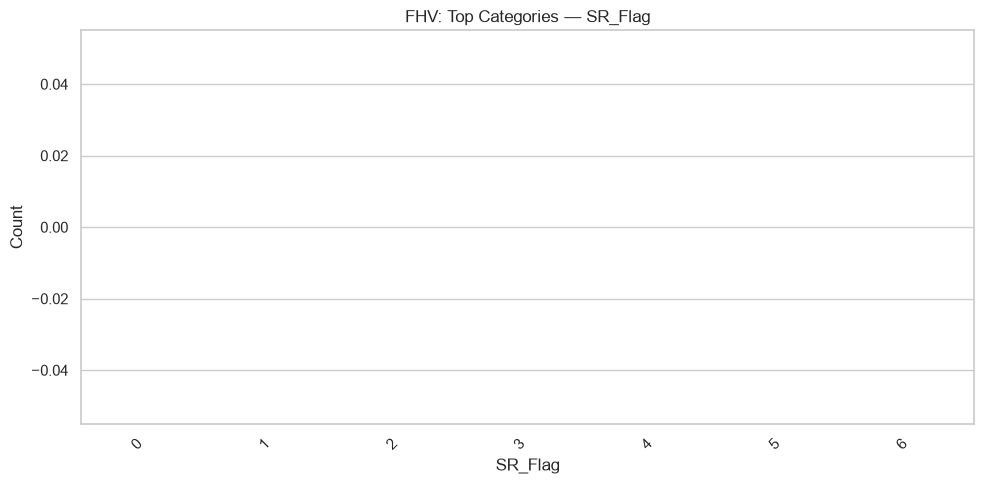

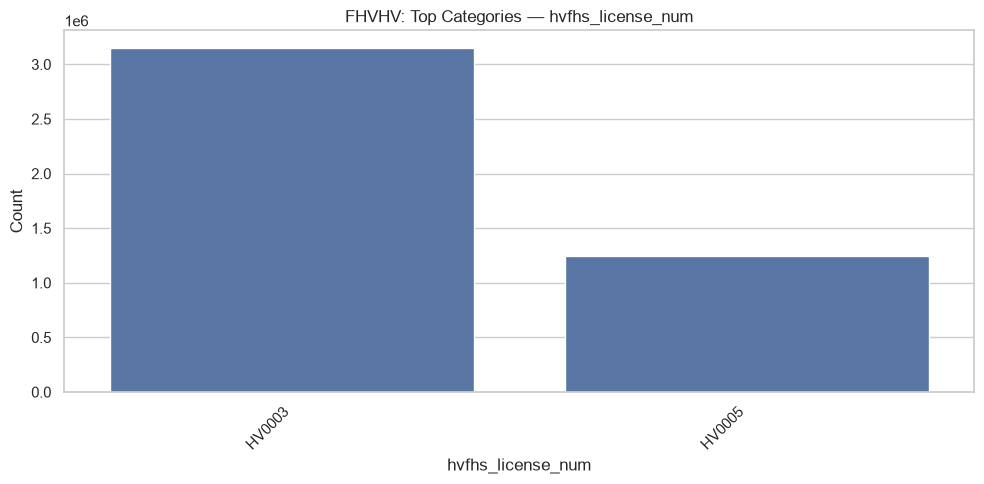

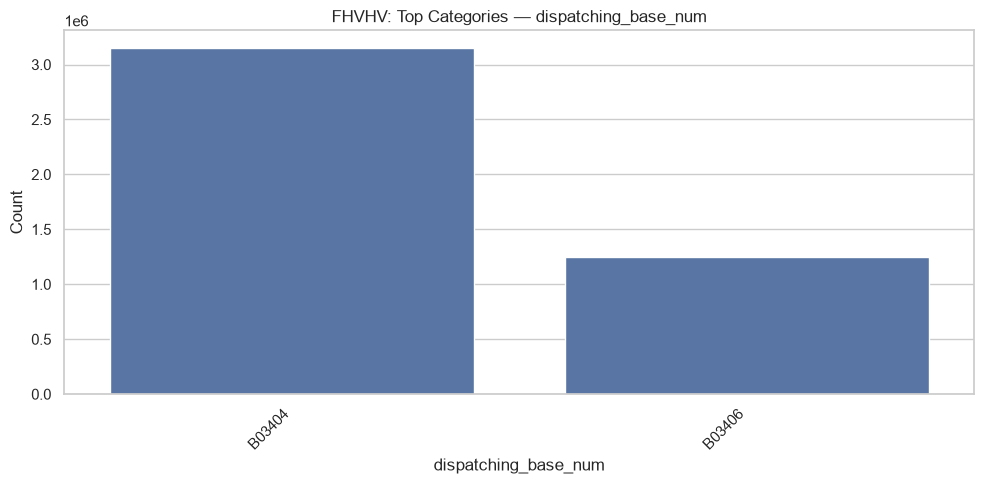

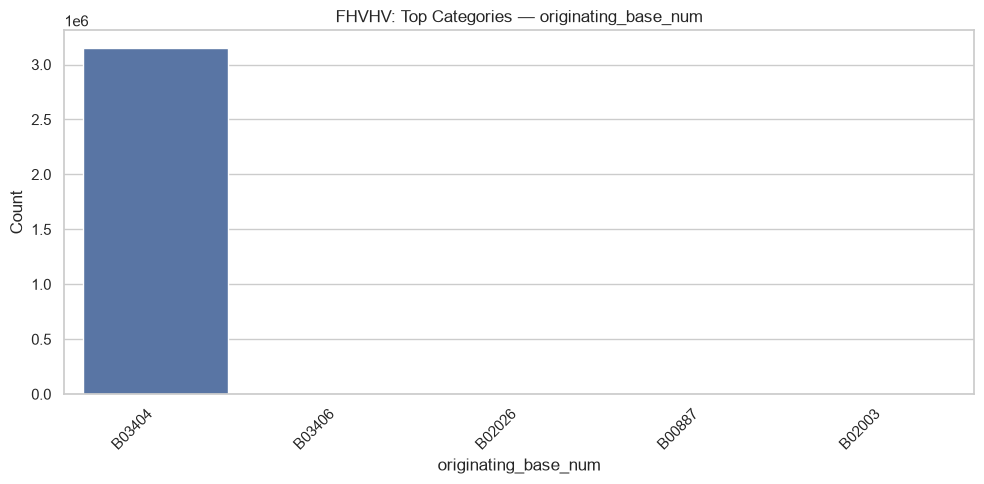

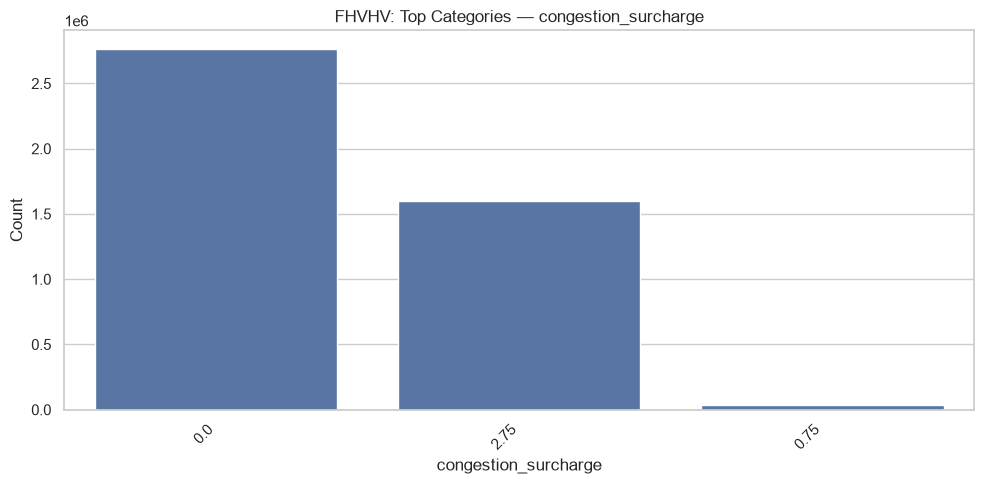

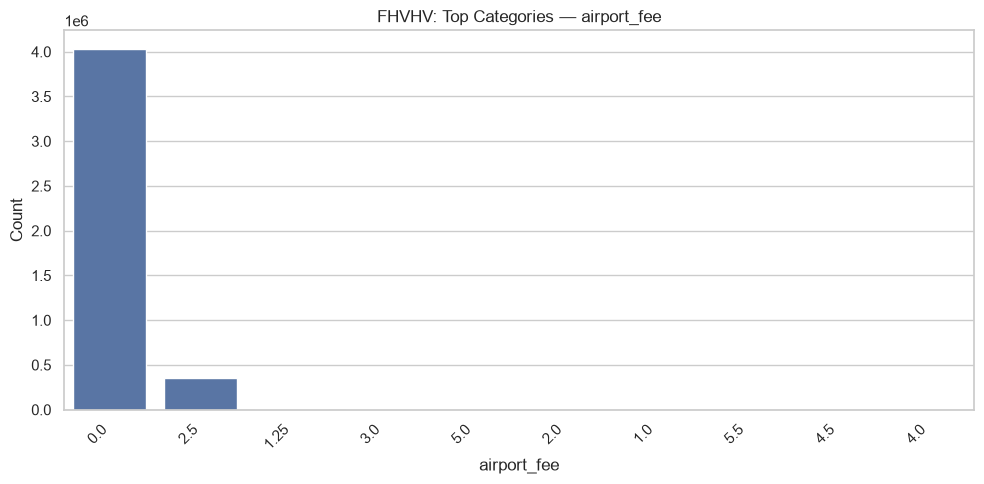

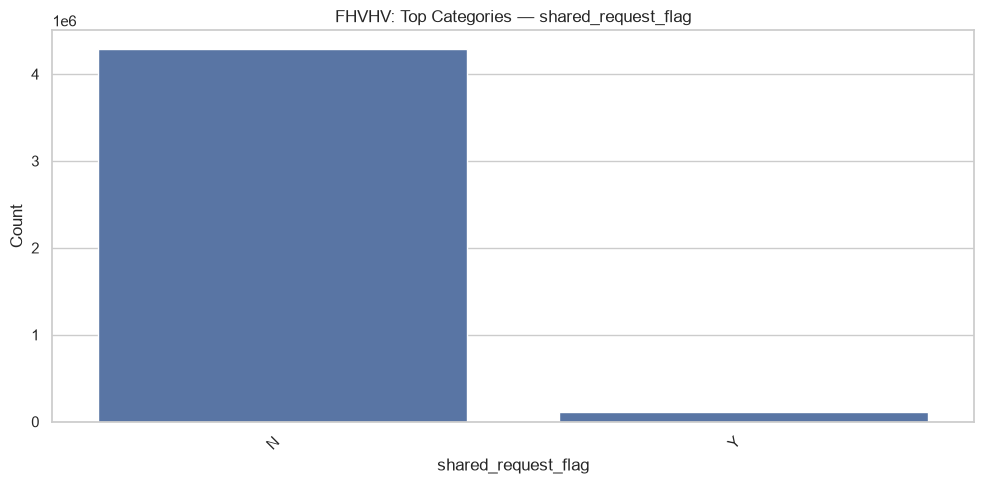

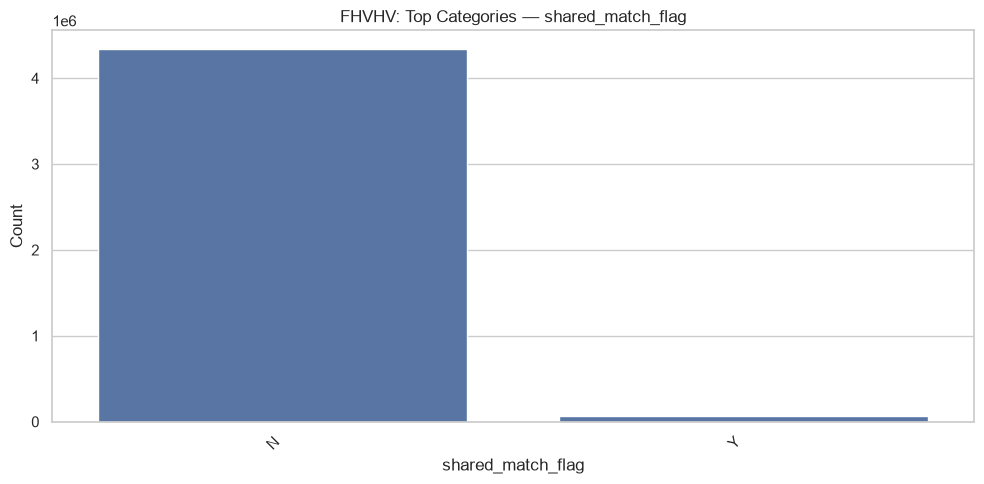

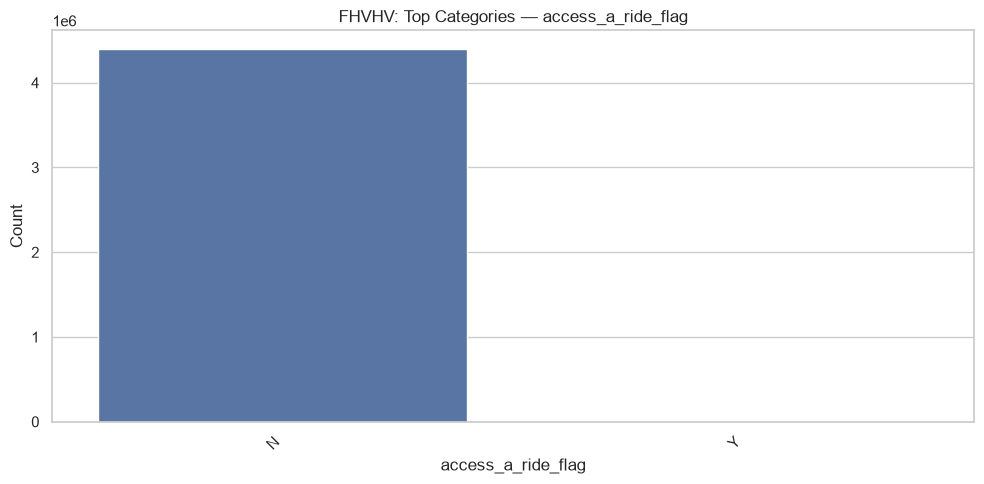

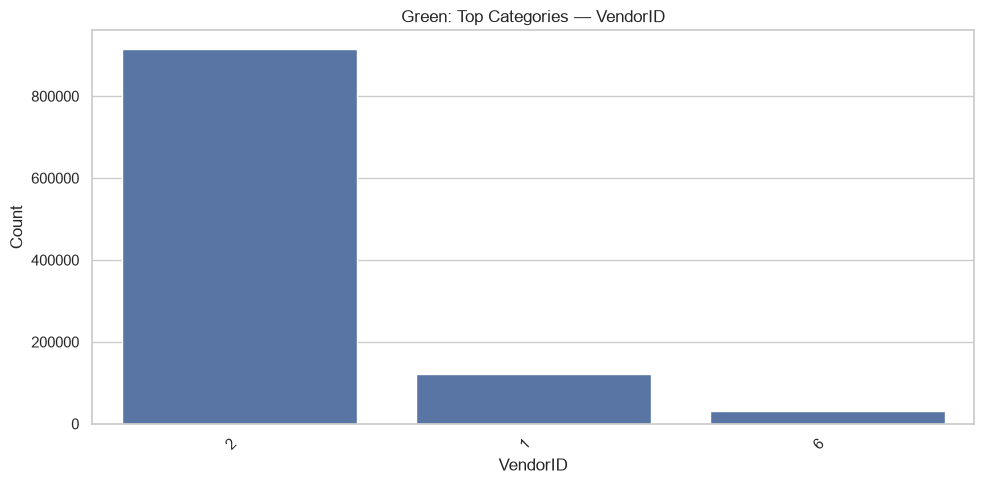

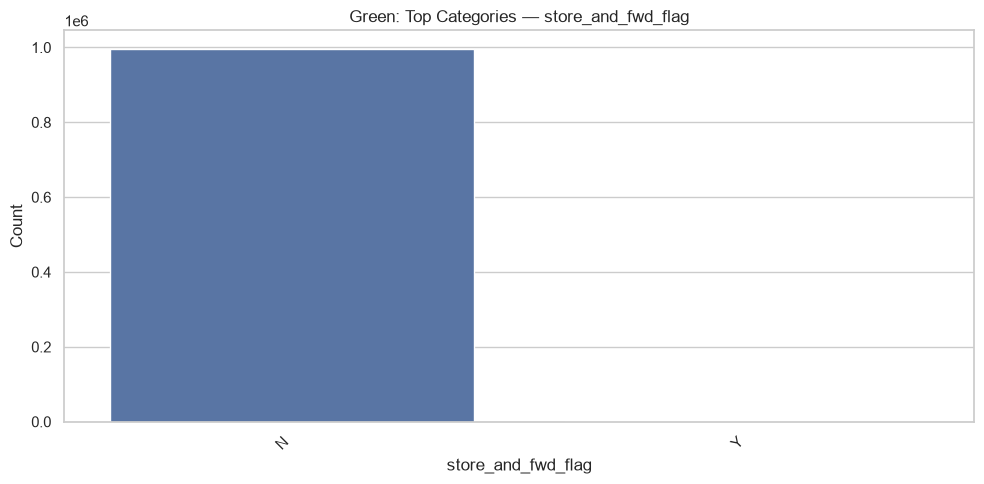

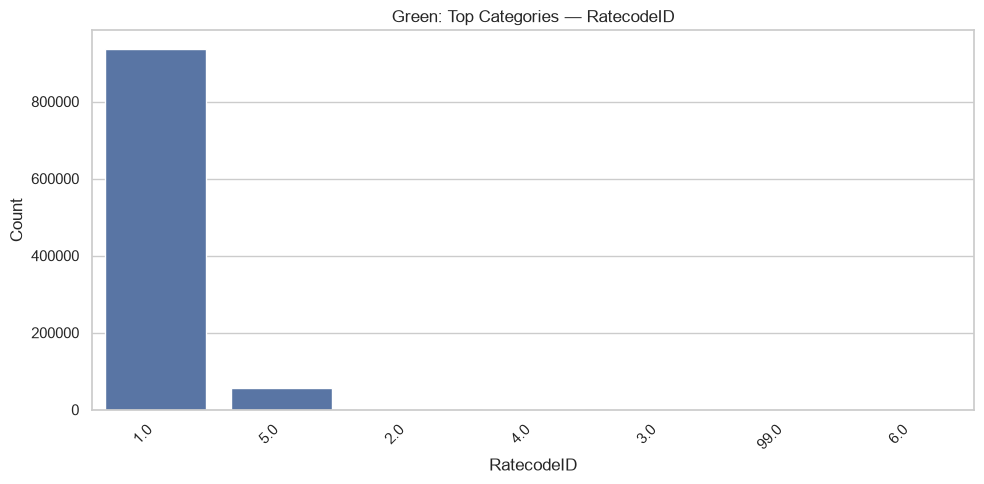

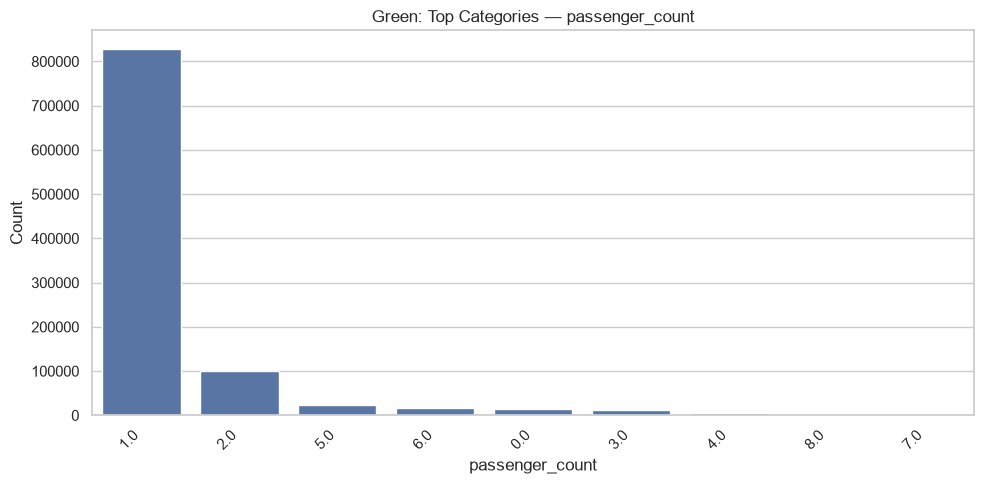

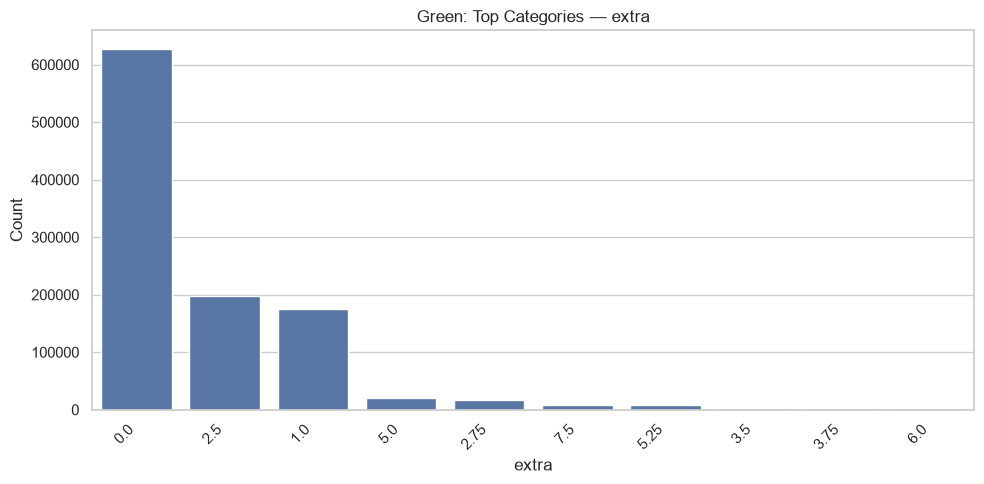

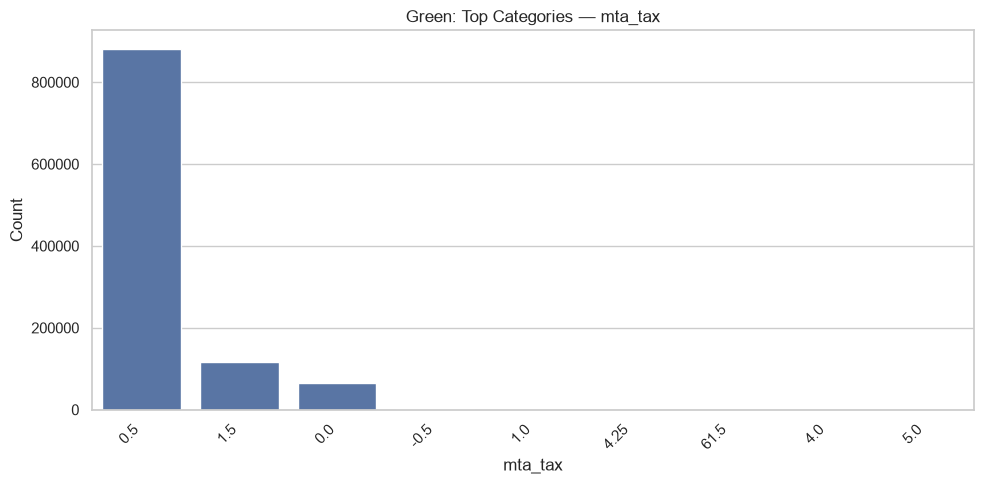

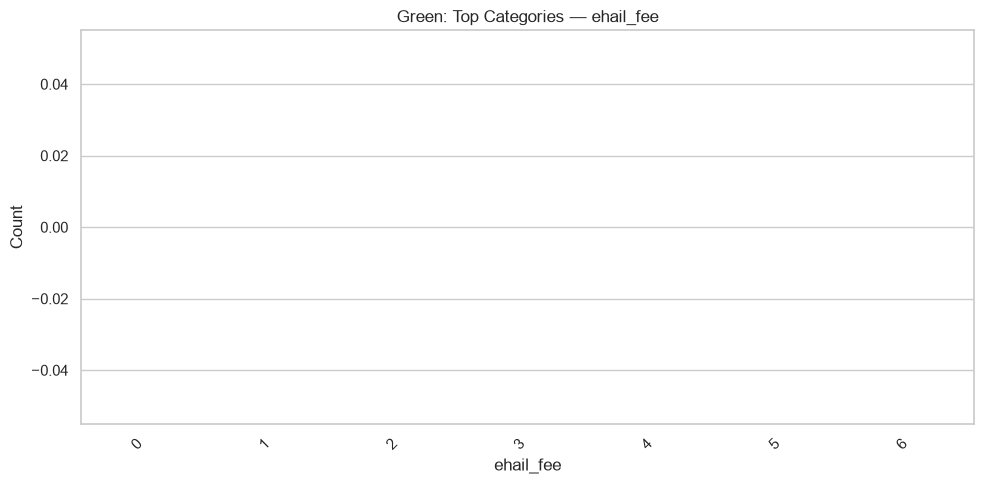

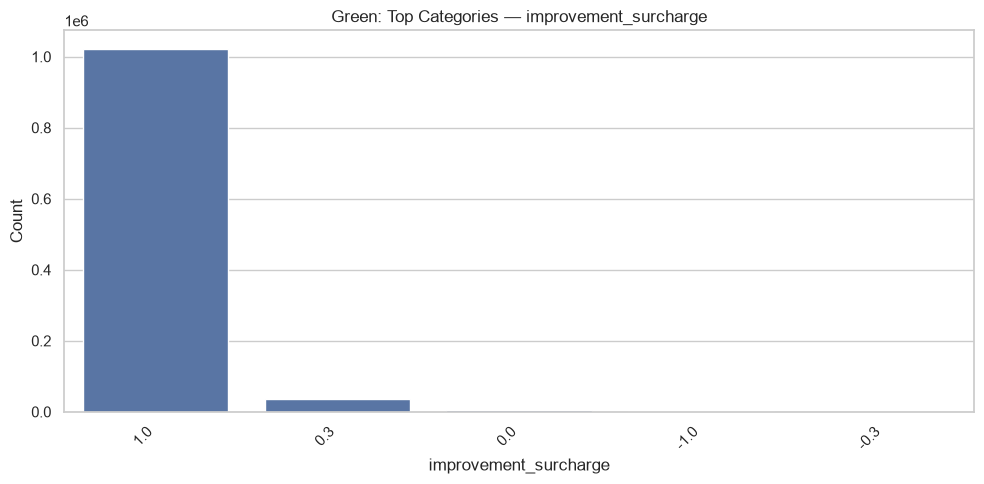

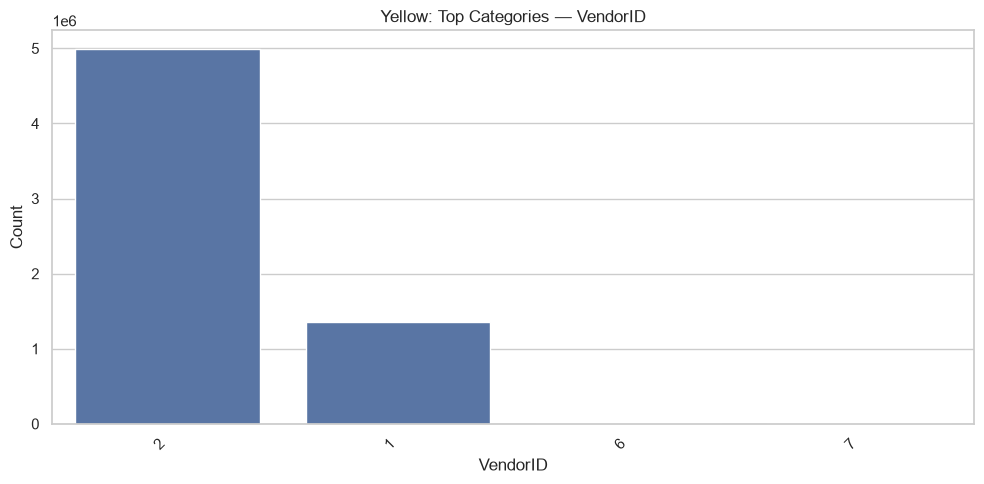

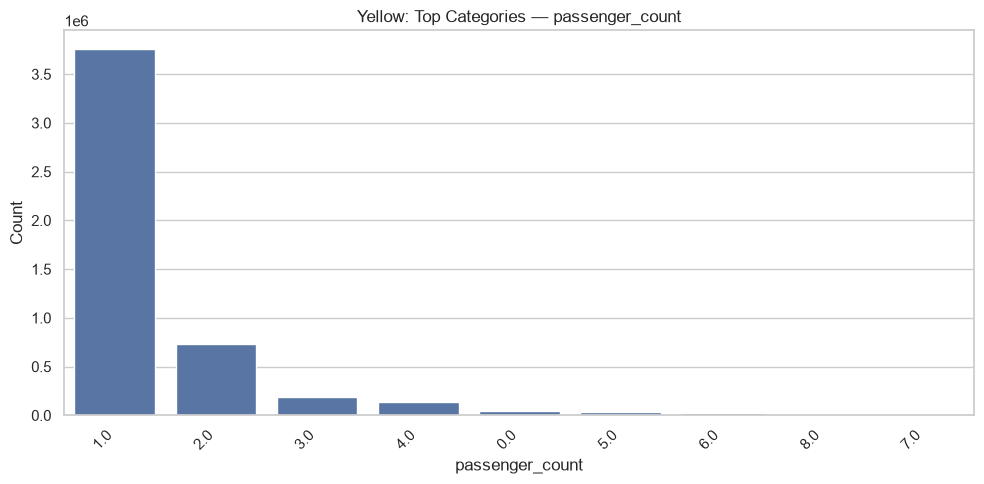

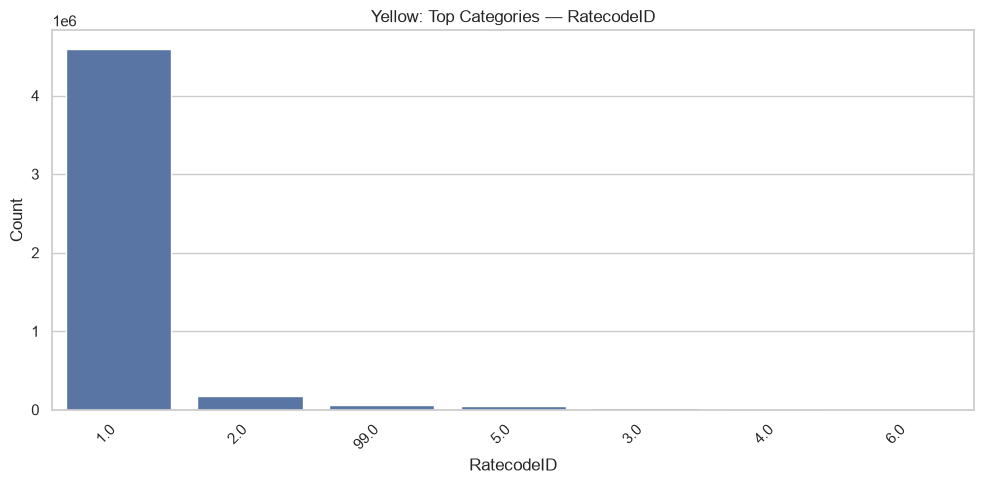

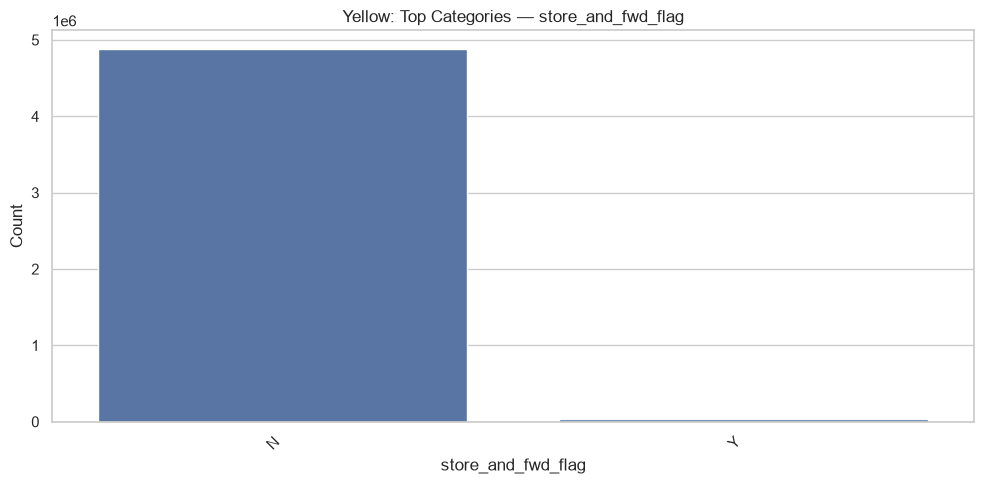

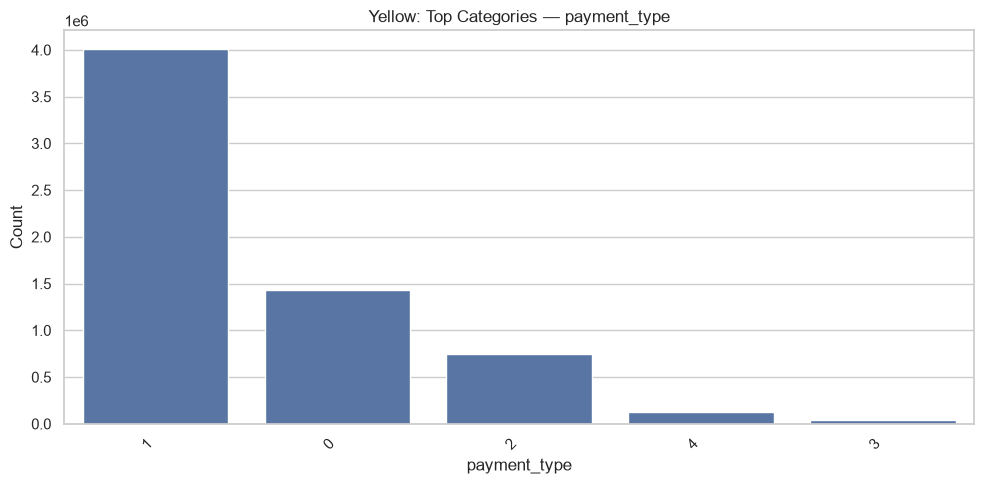

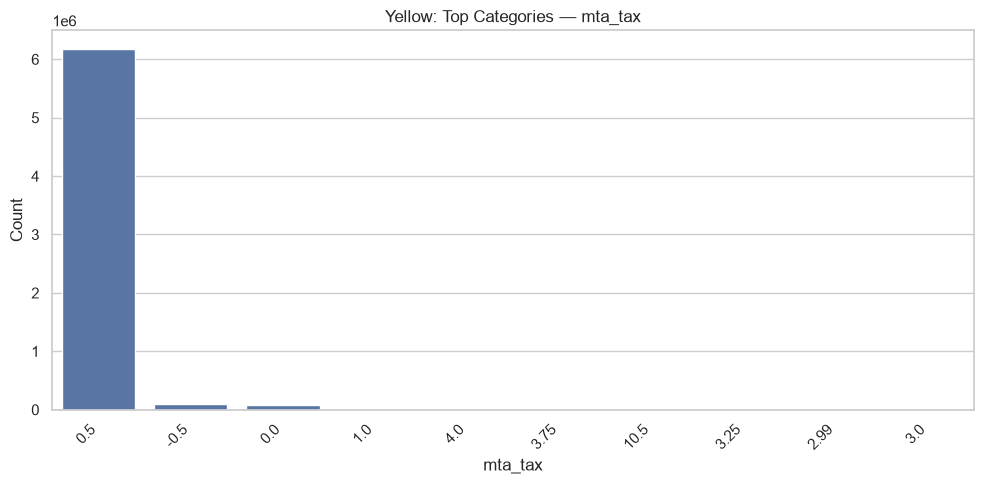

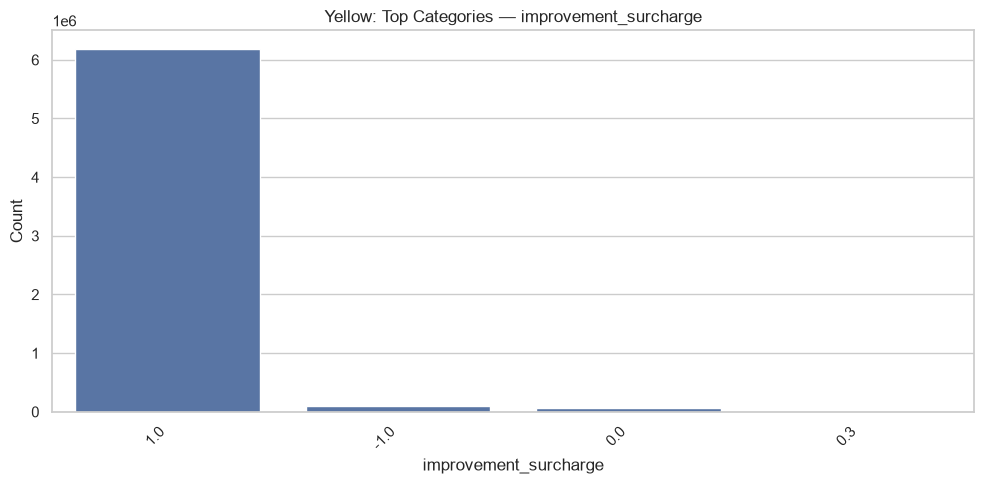

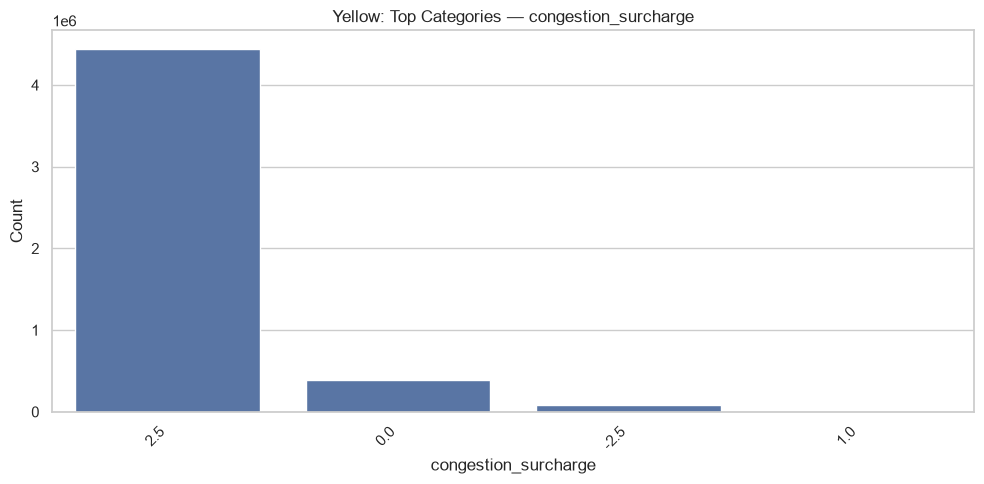

In [12]:
for name, df in samples.items():
    cats = categorical_columns(df)
    # Limit plots so the notebook stays responsive.
    for col in cats[:8]:
        counts = df[col].value_counts(dropna=False).head(10)
        if len(counts) == 0:
            continue
        plt.figure(figsize=(10, 5))
        sns.barplot(x=counts.index.astype(str), y=counts.values)
        plt.title(f"{name}: Top Categories — {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## 8. Univariate Analysis — Numerical Variables

In [13]:
def numeric_columns(df):
    return df.select_dtypes(include=np.number).columns.tolist()

for name, df in samples.items():
    nums = numeric_columns(df)
    print(f"{name}: {len(nums)} numeric columns")
    print(nums[:30])

FHV: 3 numeric columns
['PUlocationID', 'DOlocationID', 'SR_Flag']
FHVHV: 13 numeric columns
['PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'cbd_congestion_fee']
Green: 18 numeric columns
['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']
Yellow: 17 numeric columns
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


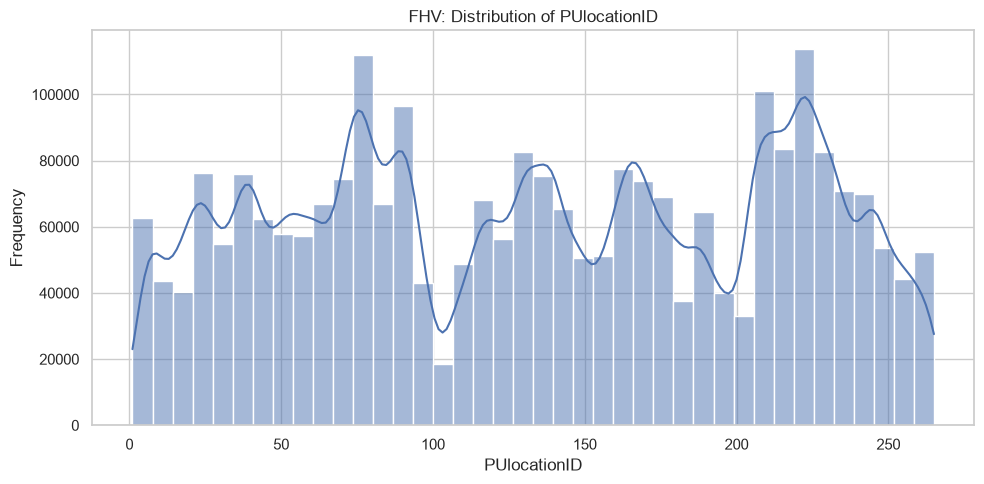

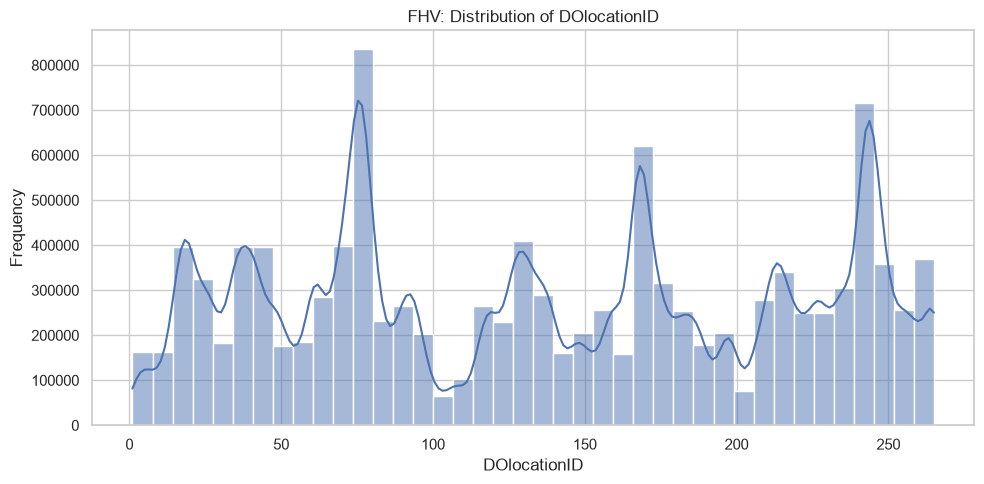

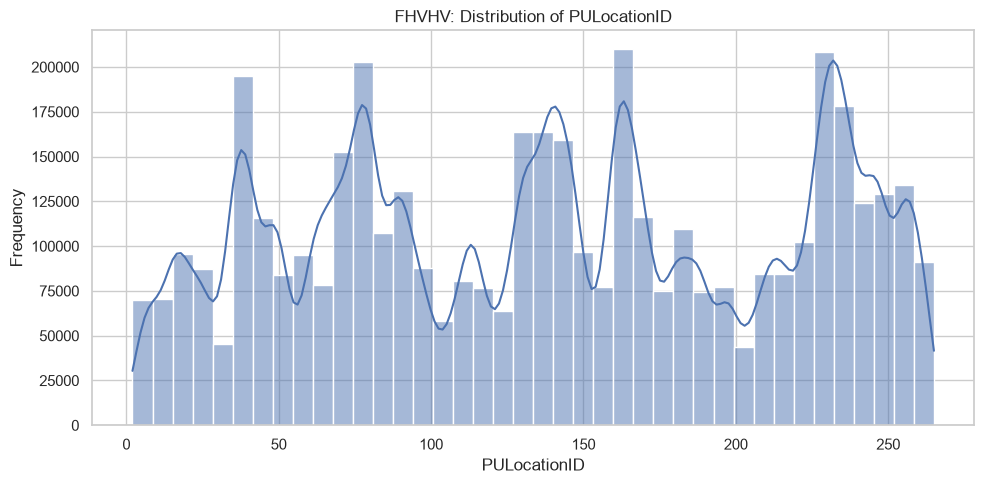

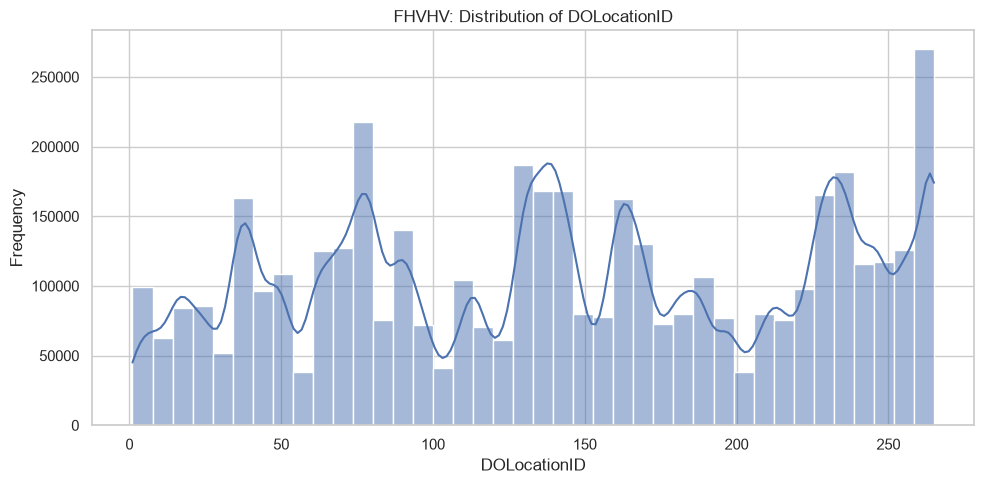

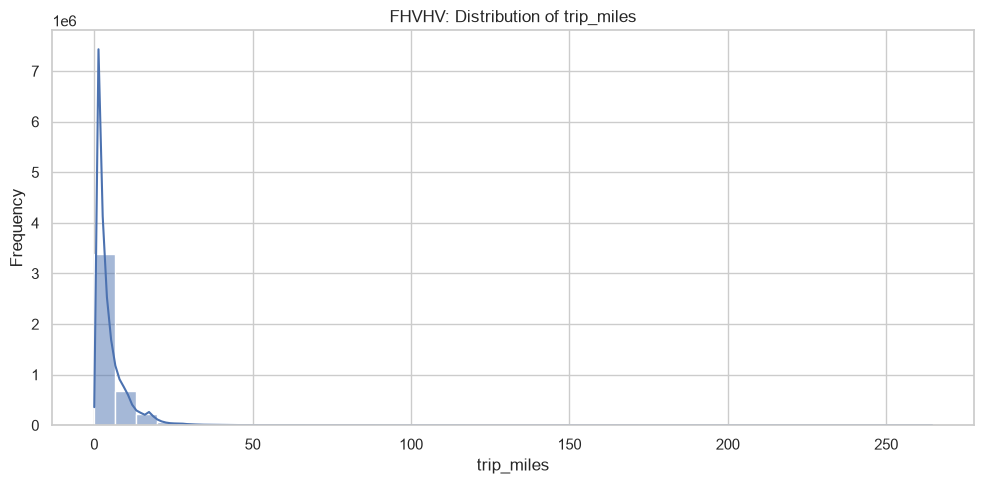

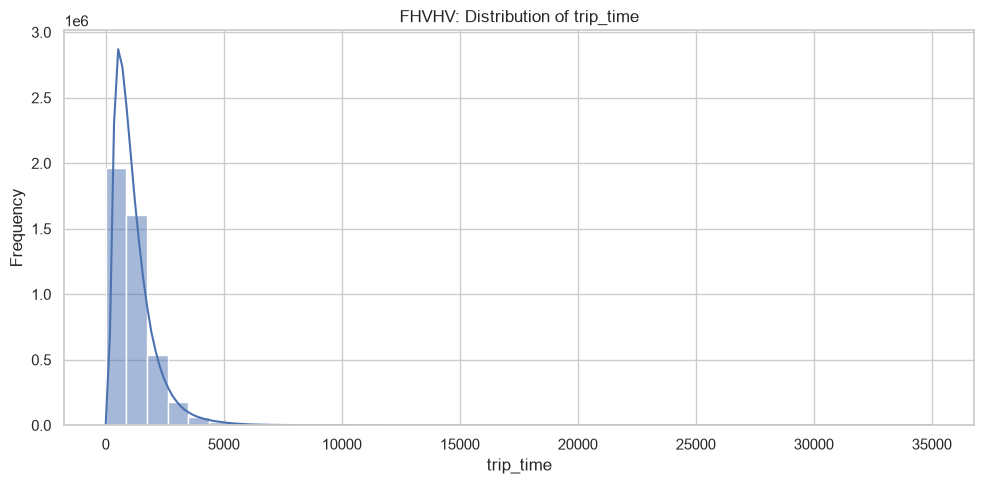

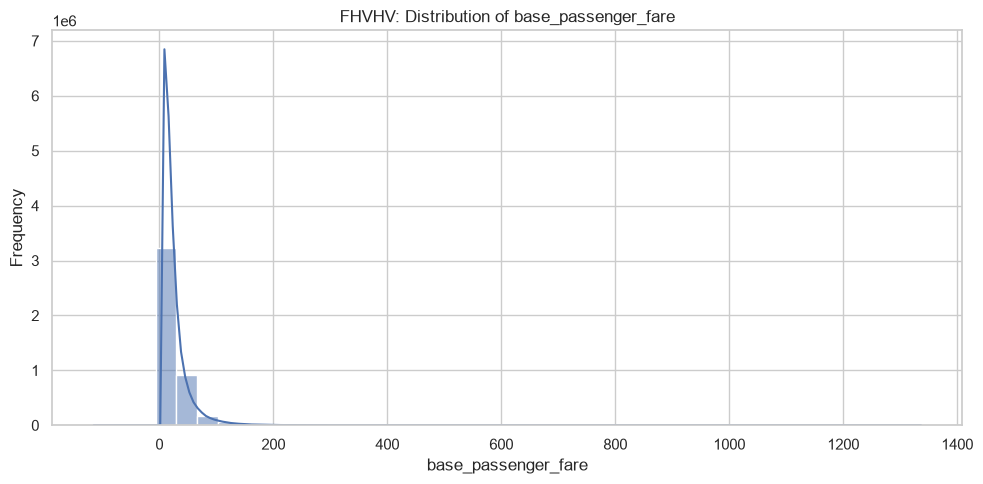

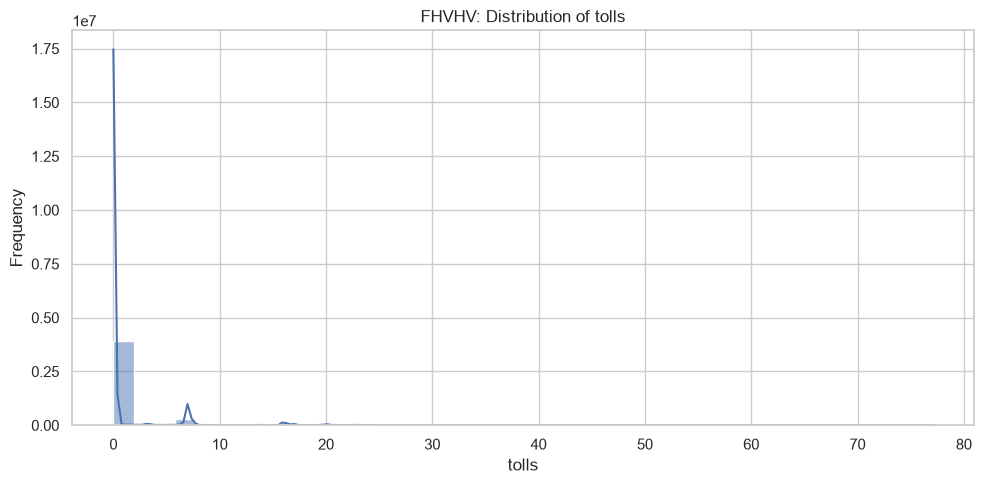

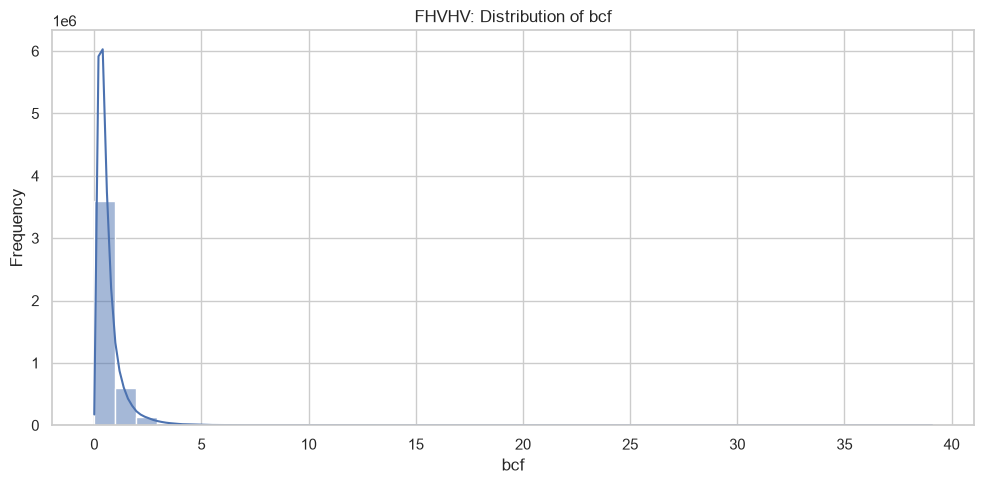

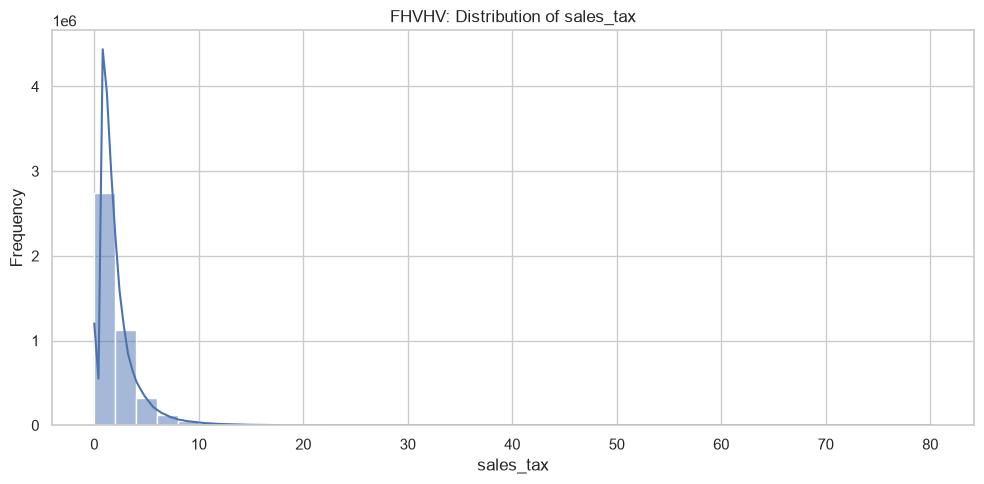

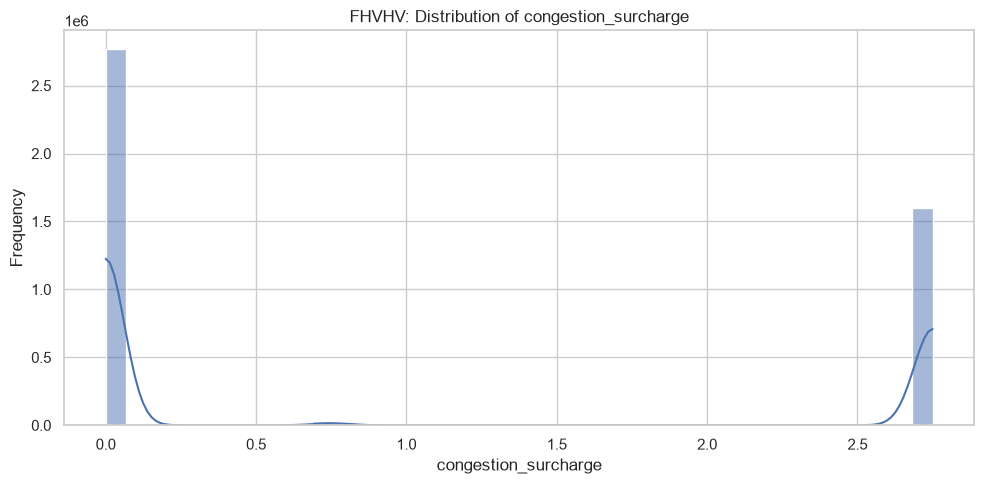

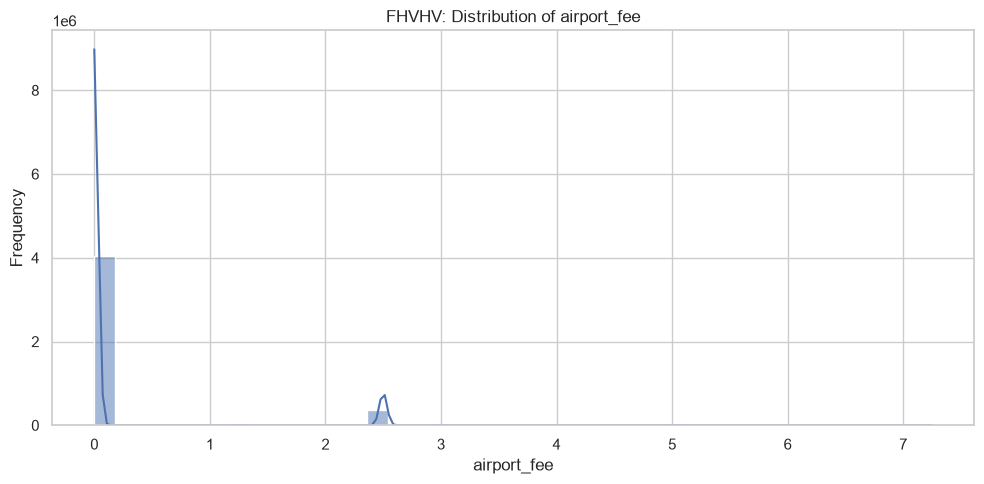

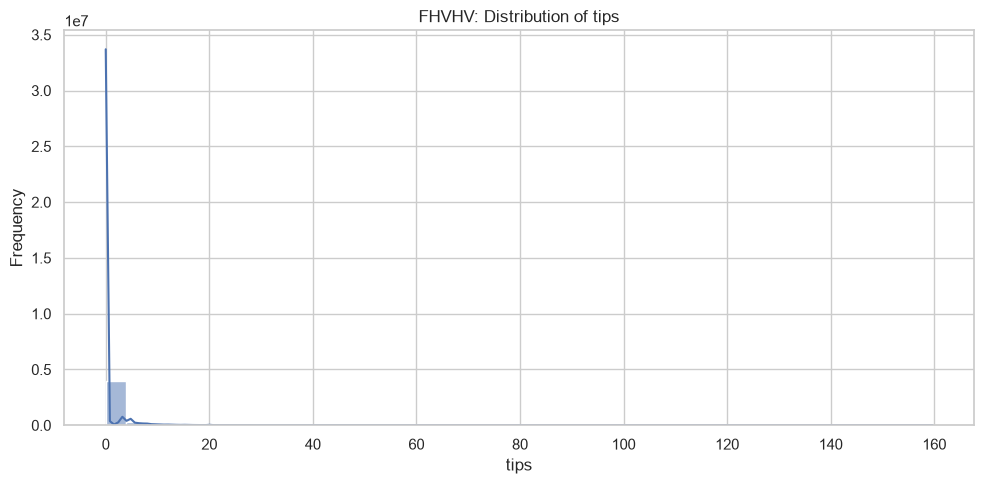

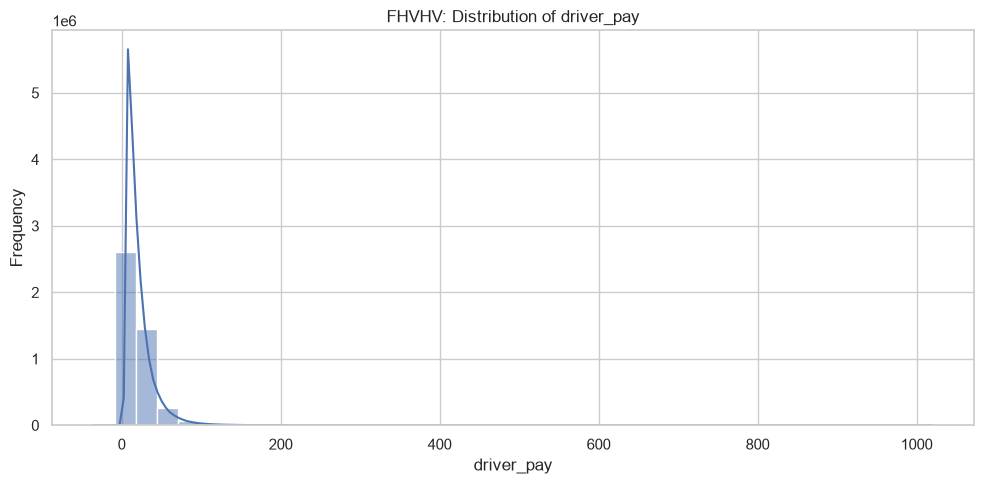

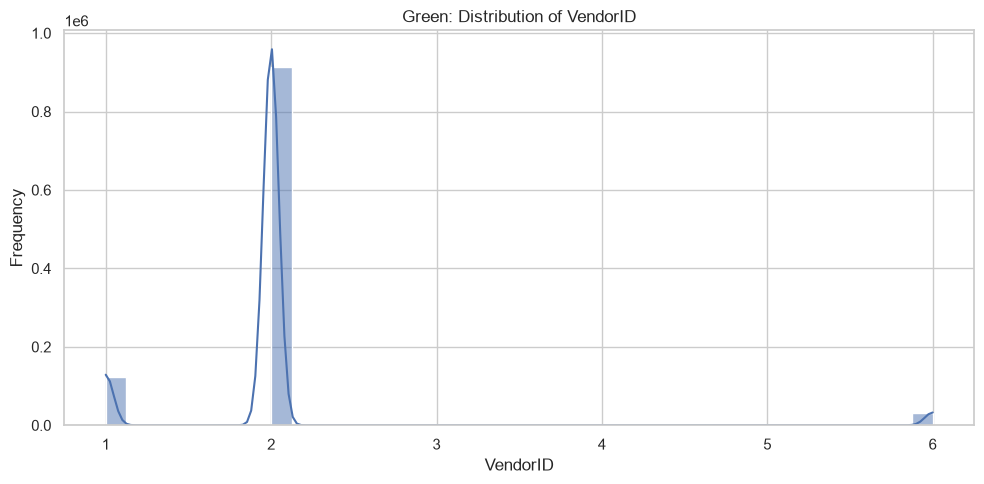

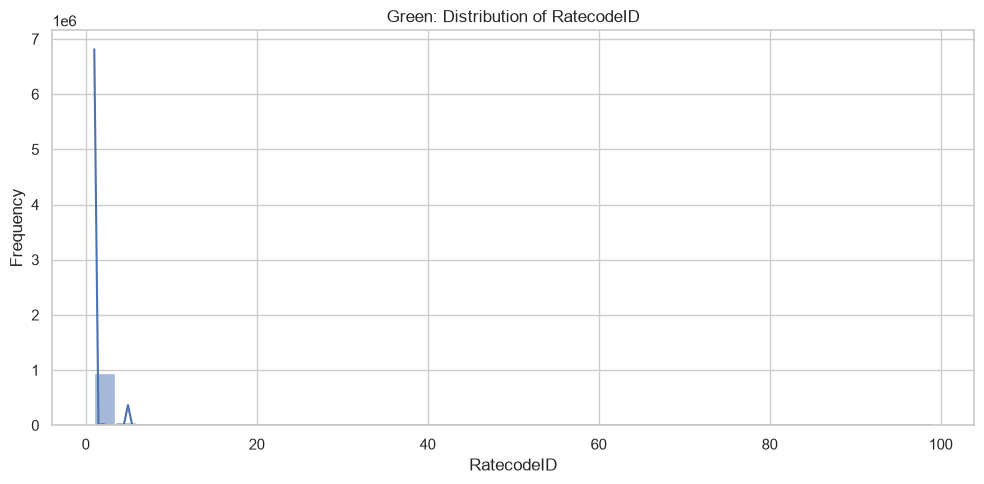

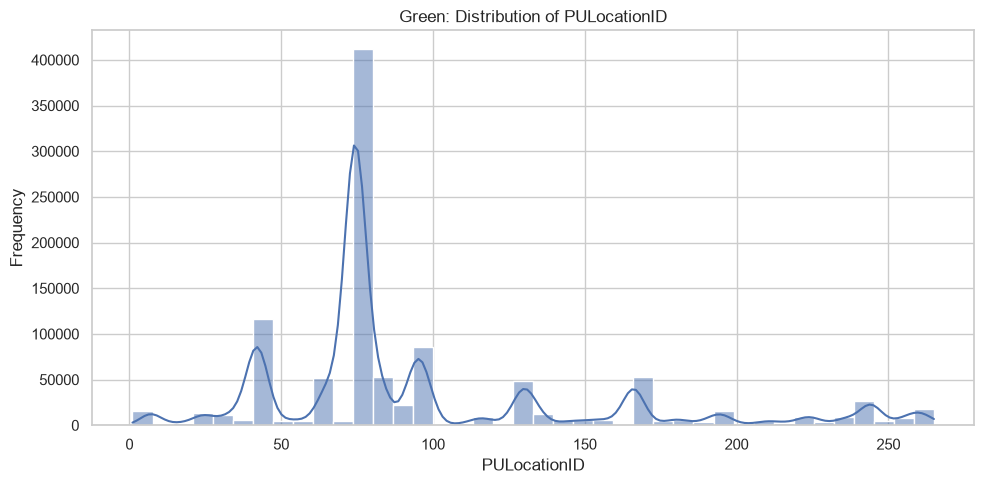

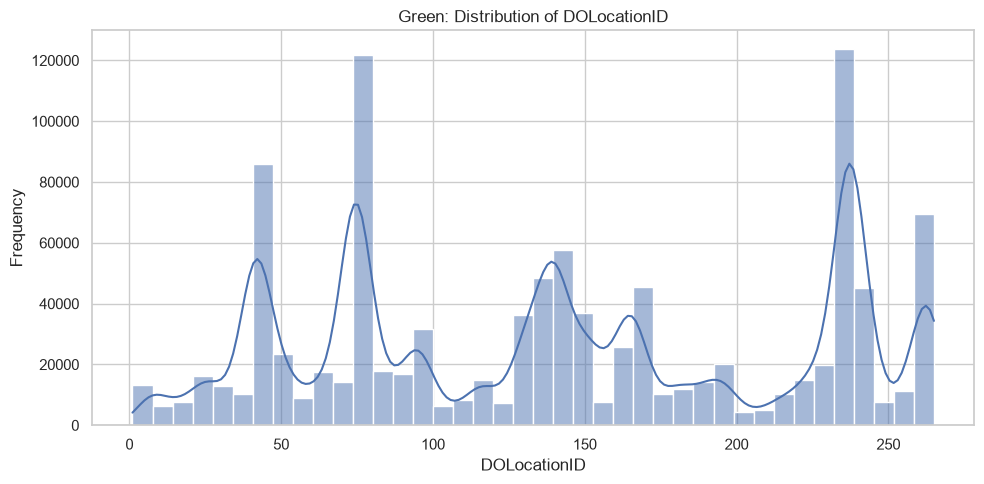

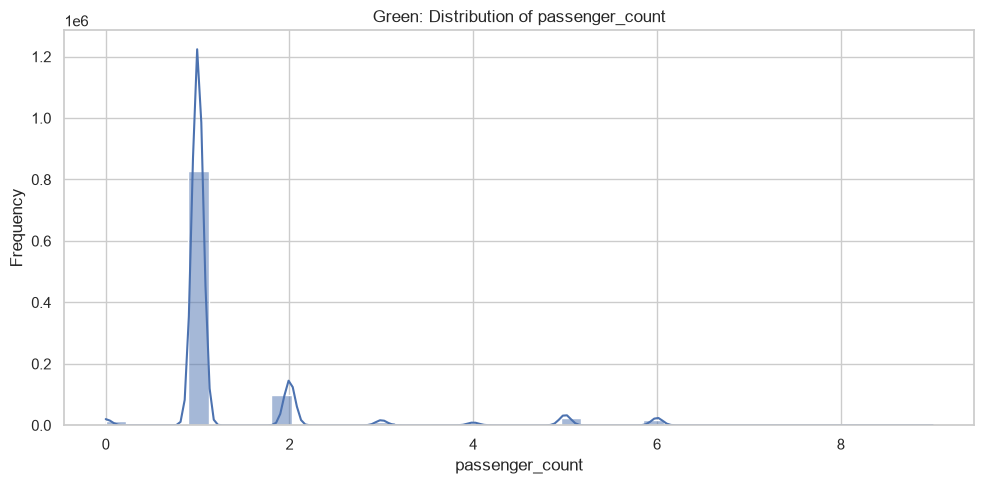

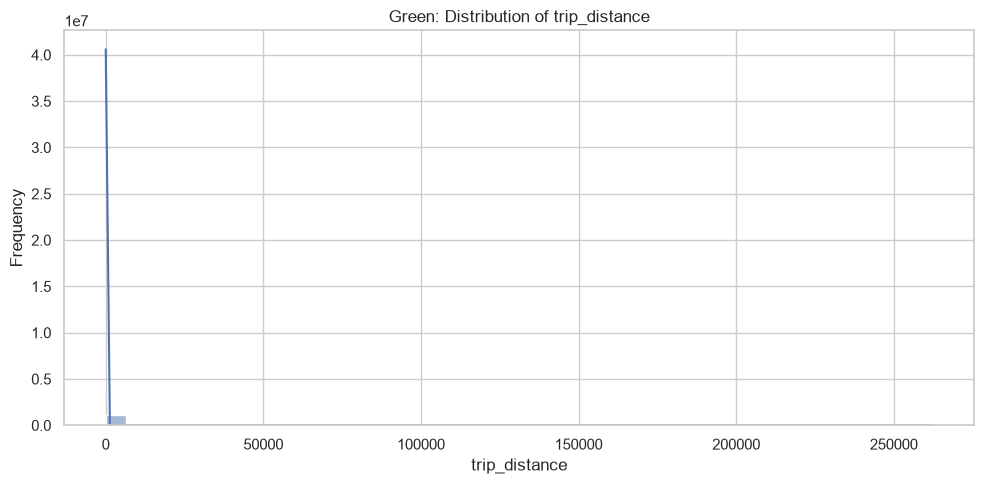

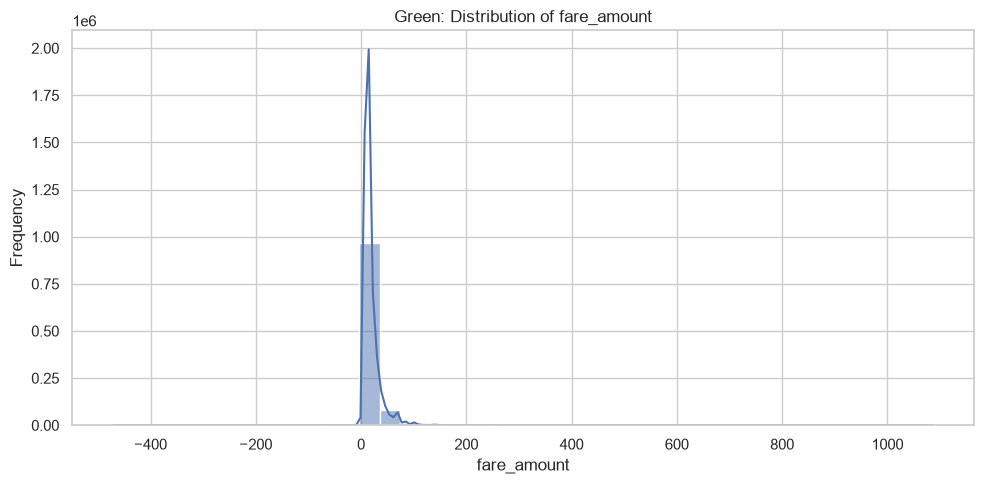

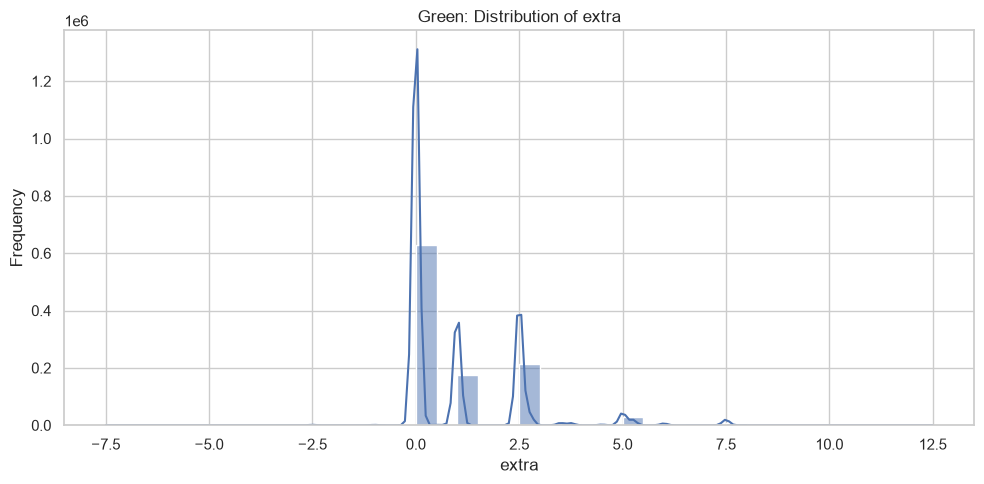

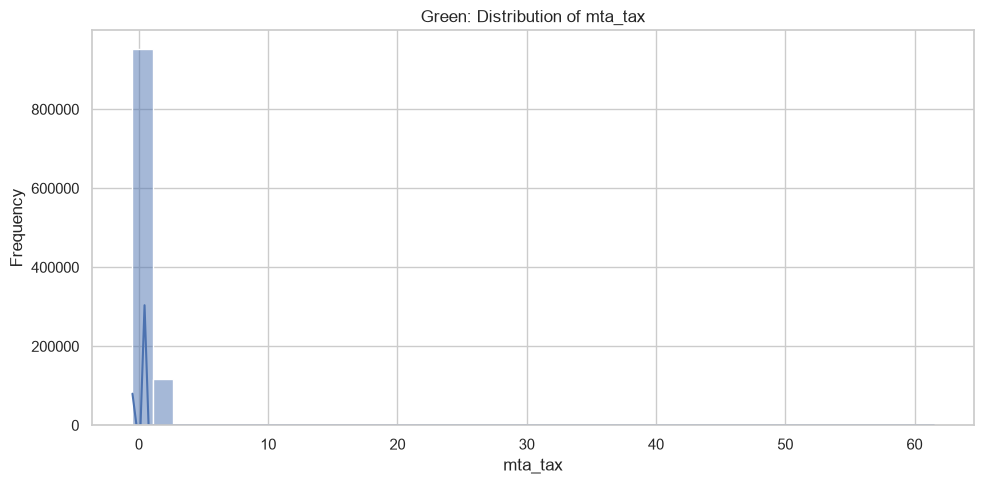

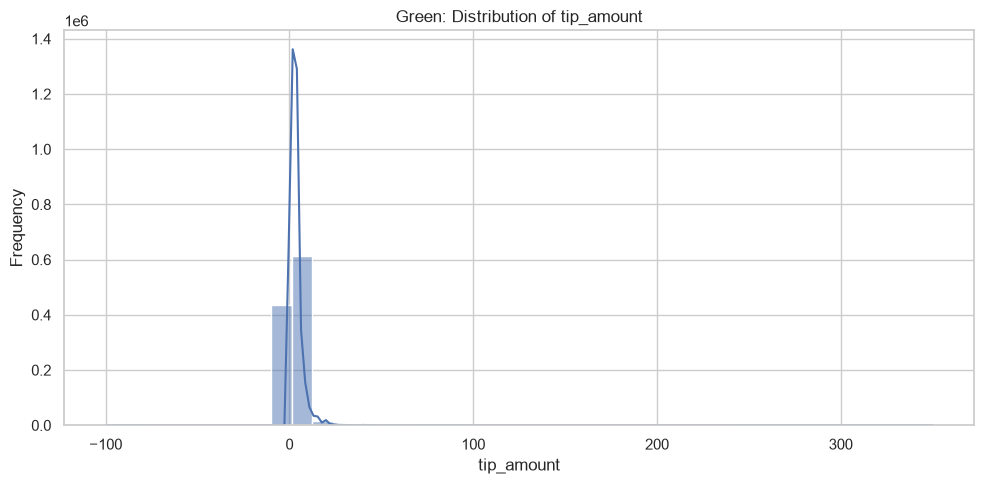

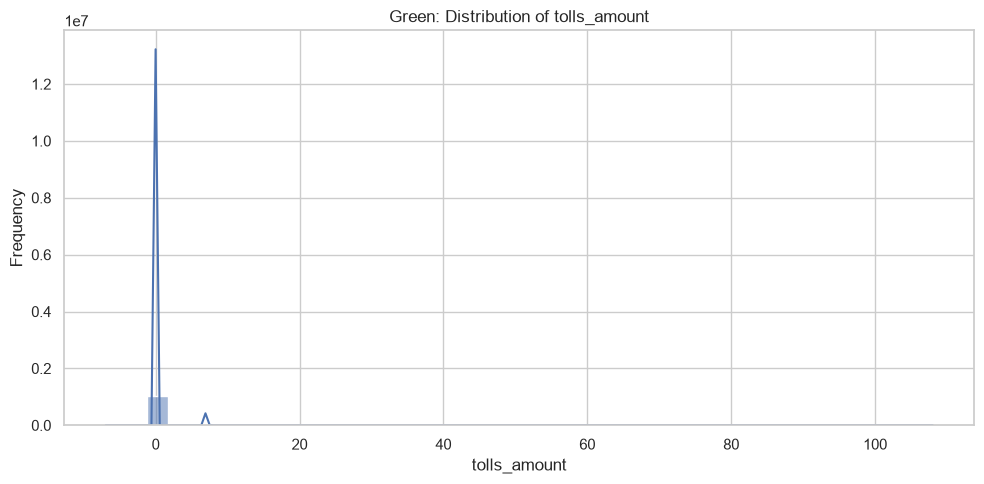

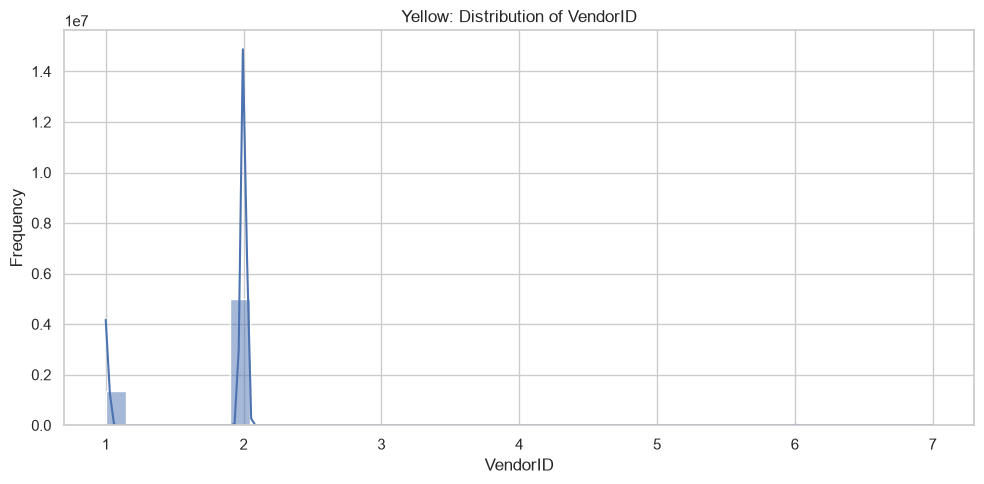

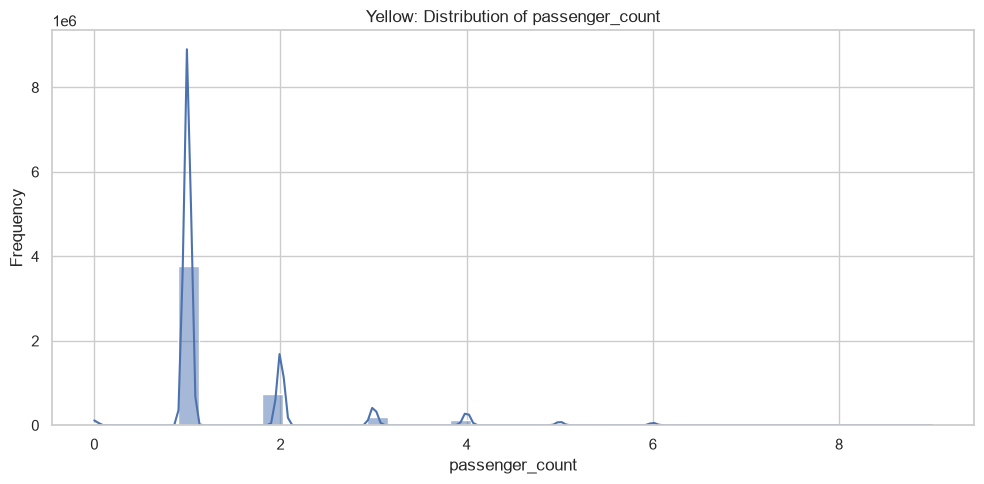

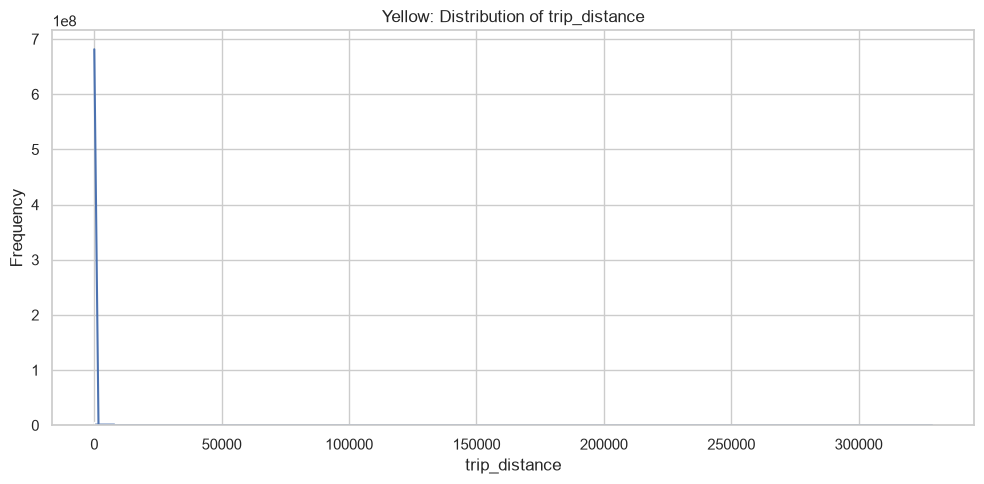

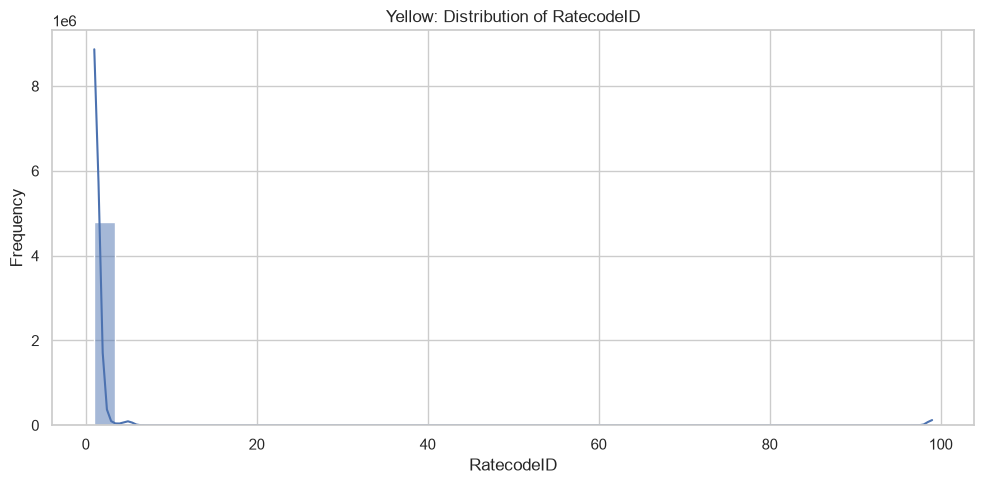

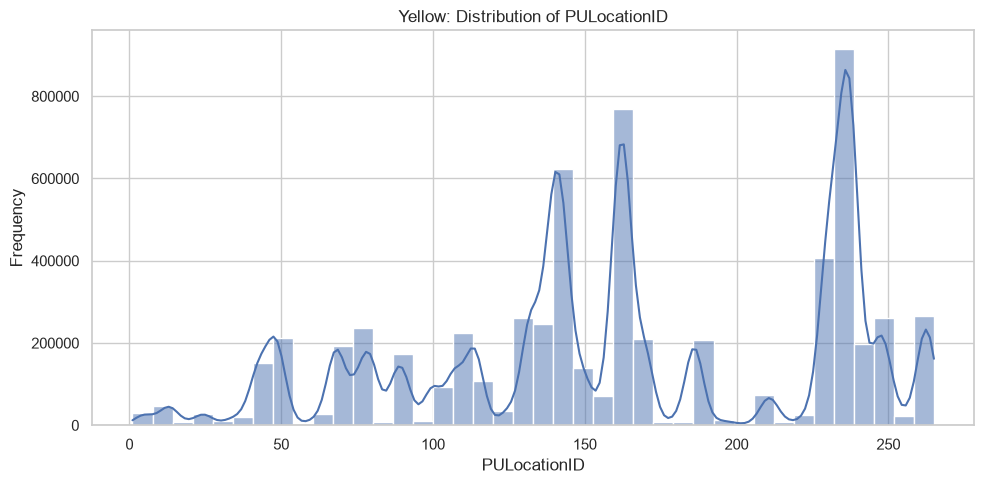

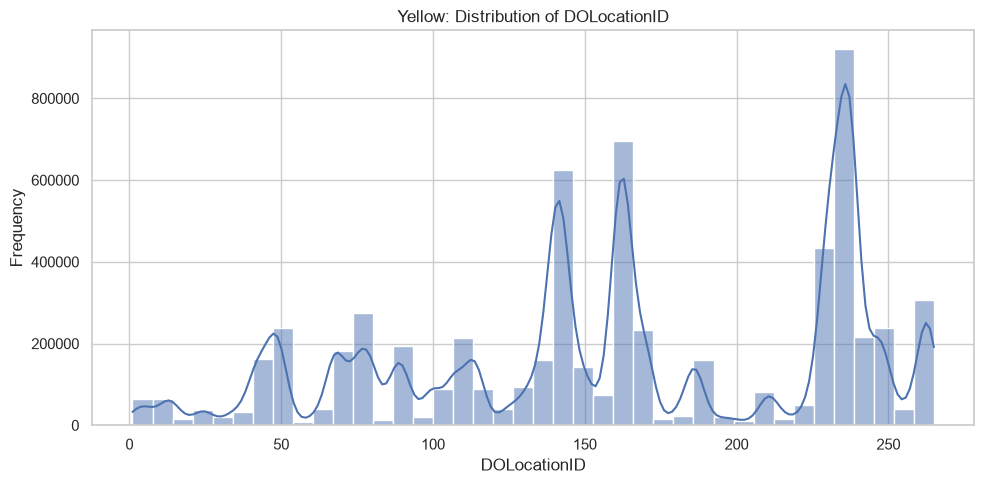

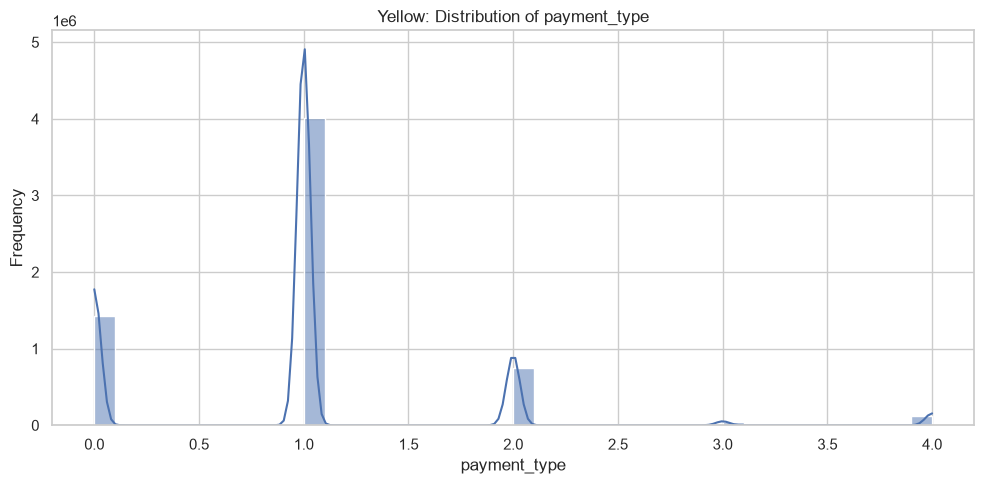

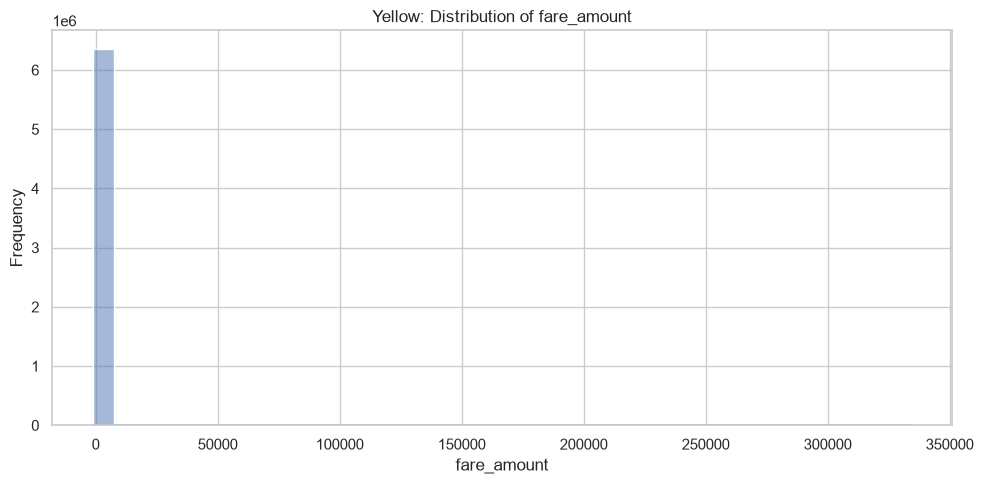

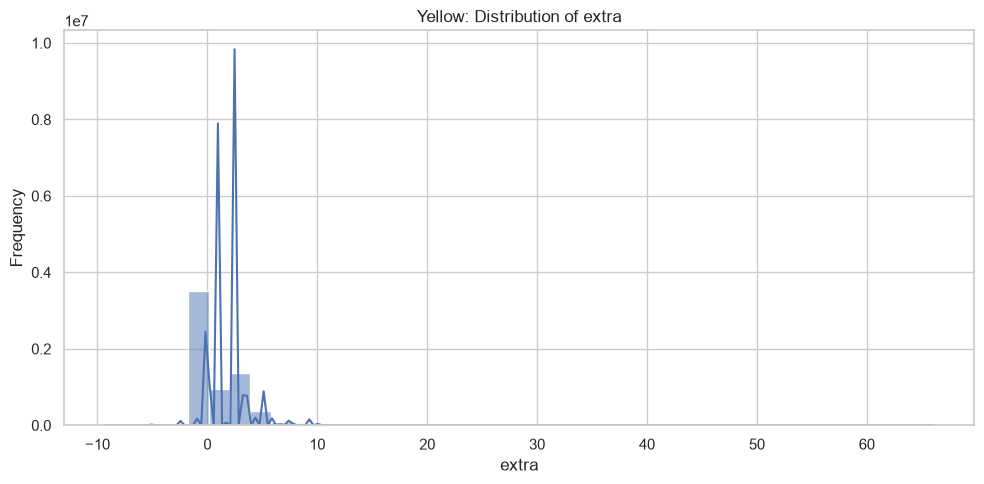

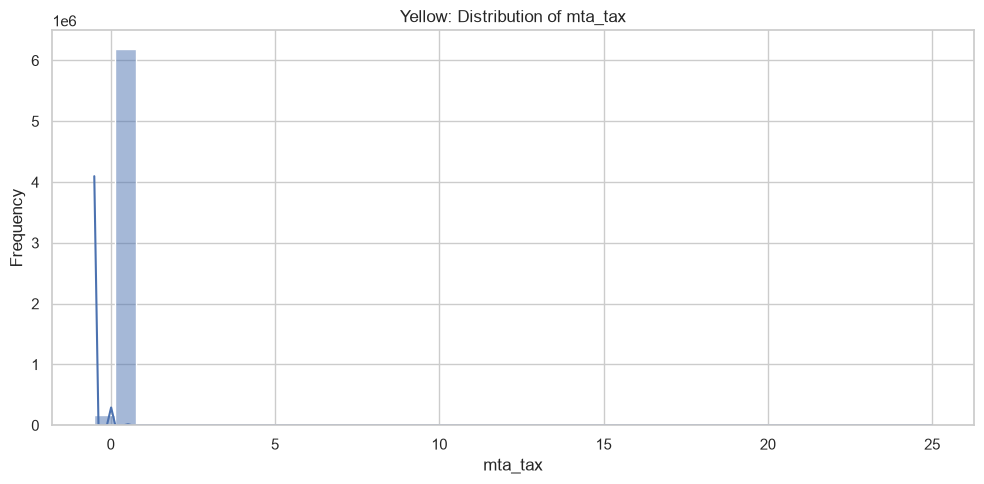

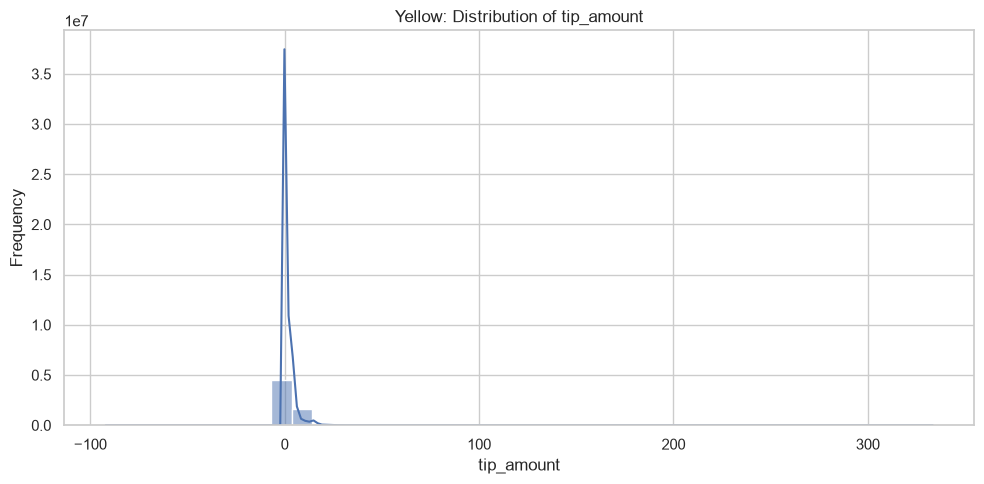

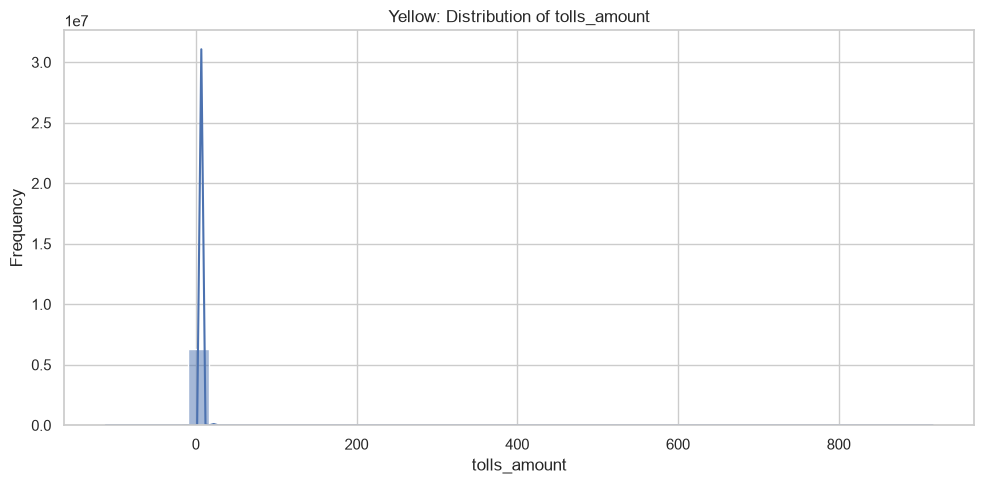

In [14]:
for name, df in samples.items():
    nums = numeric_columns(df)[:12]
    for col in nums:
        series = df[col].dropna()
        if series.empty:
            continue
        plt.figure(figsize=(10, 5))
        sns.histplot(series, bins=40, kde=True)
        plt.title(f"{name}: Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

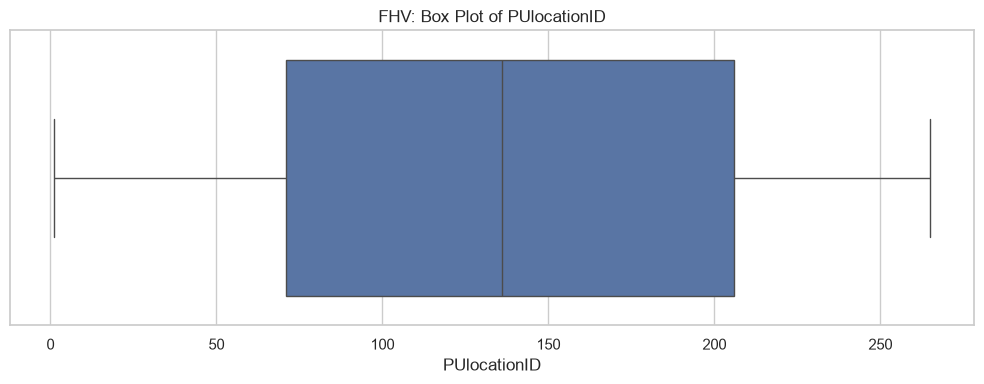

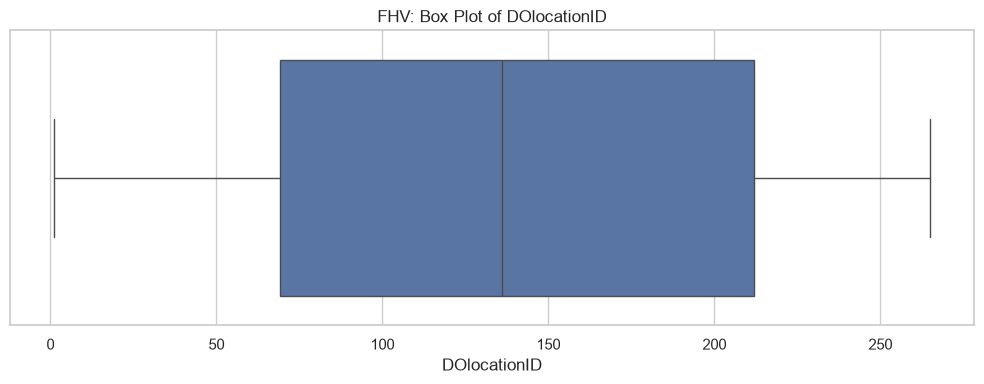

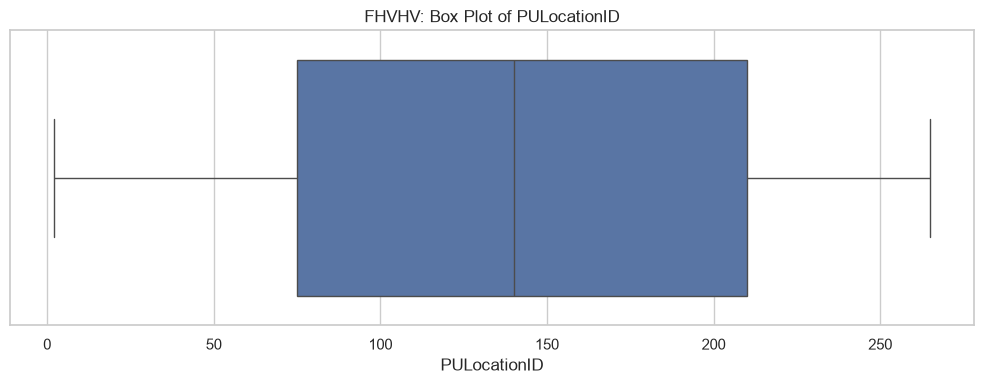

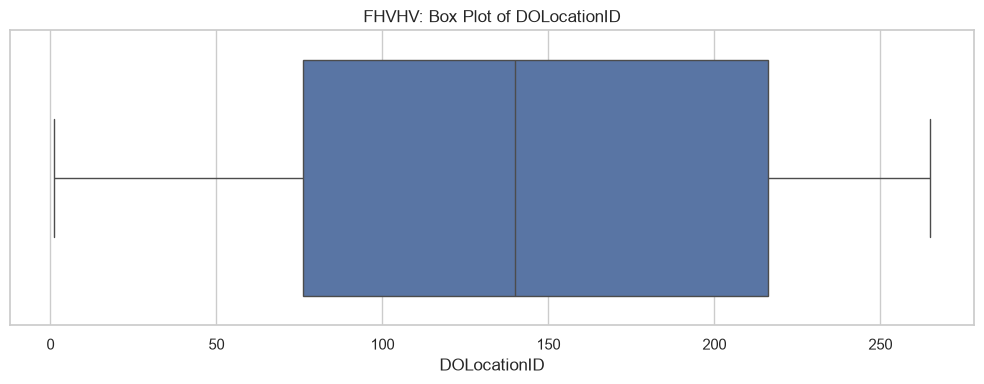

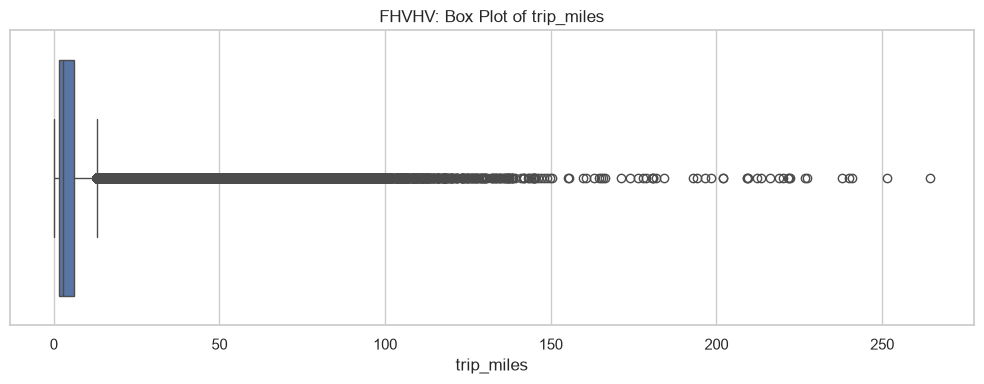

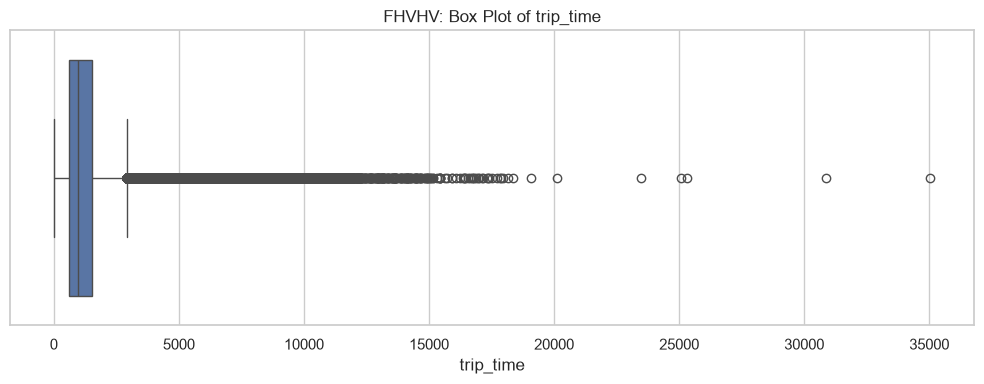

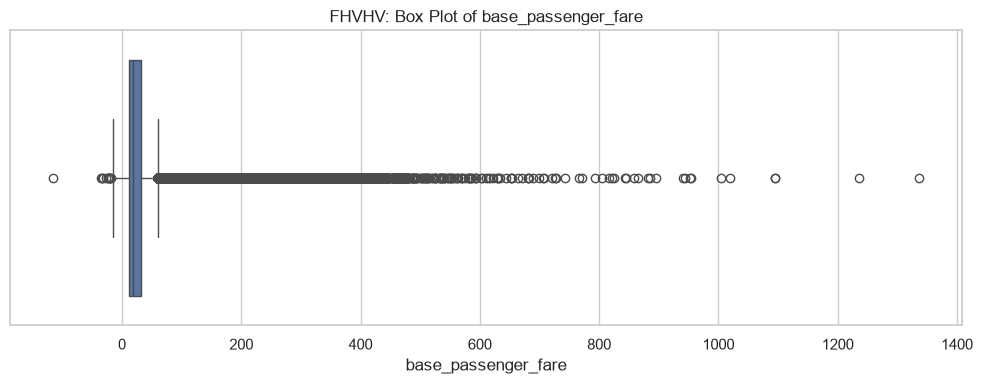

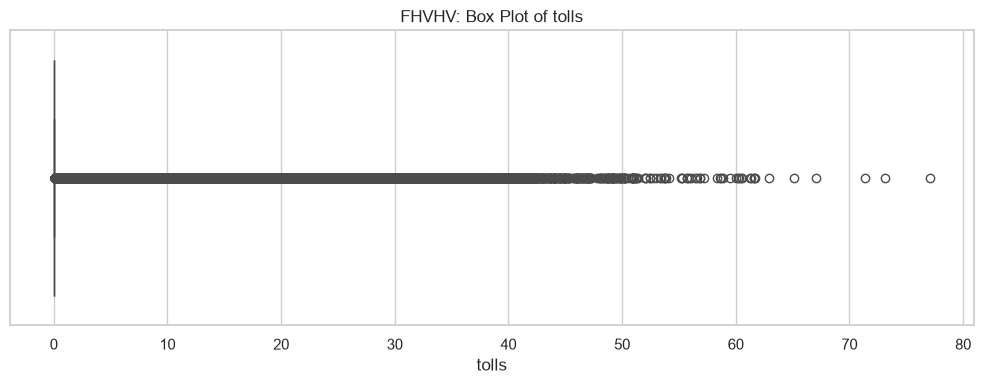

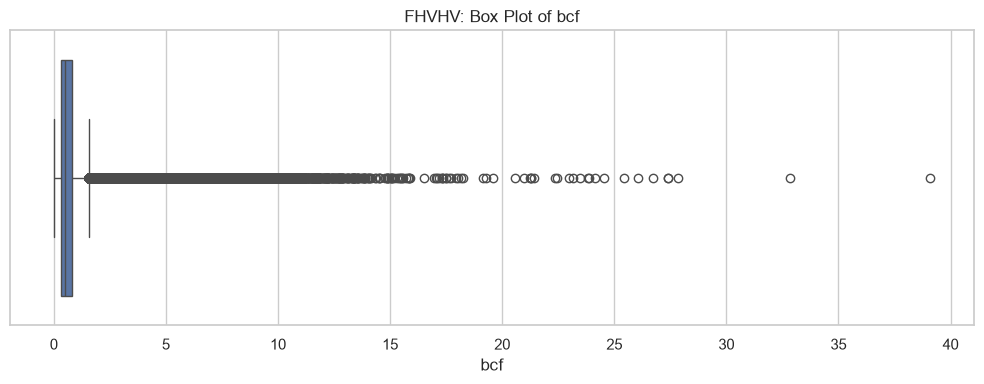

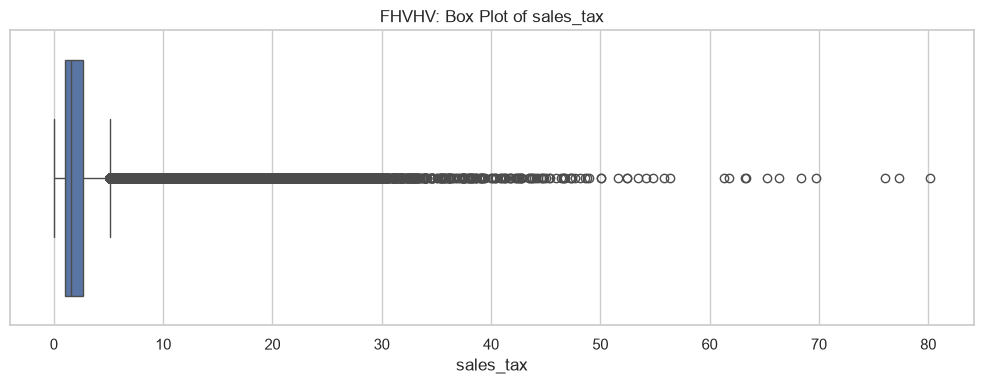

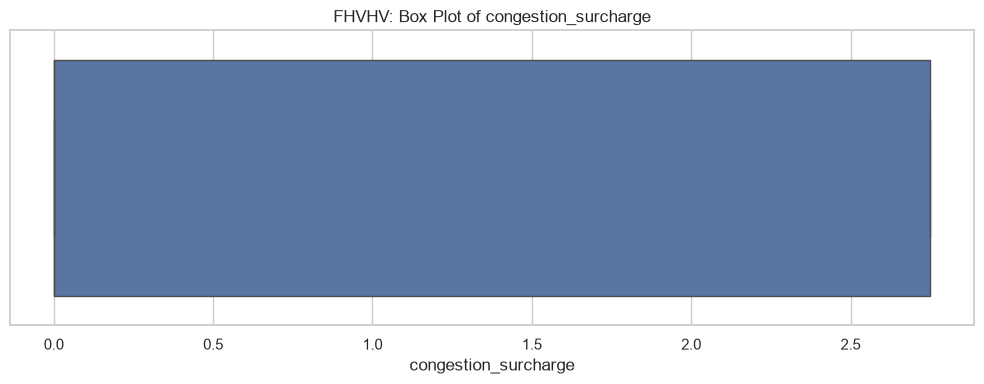

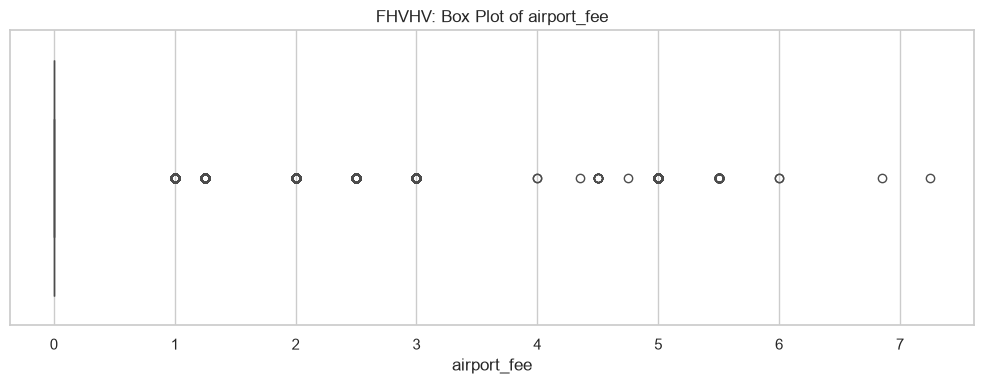

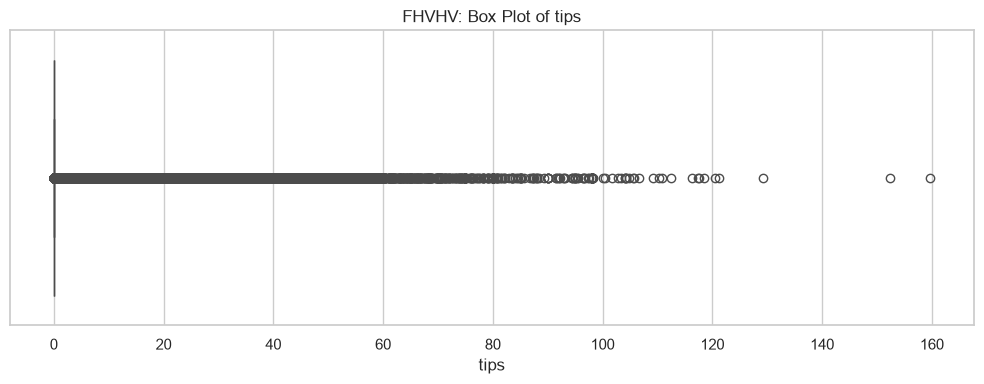

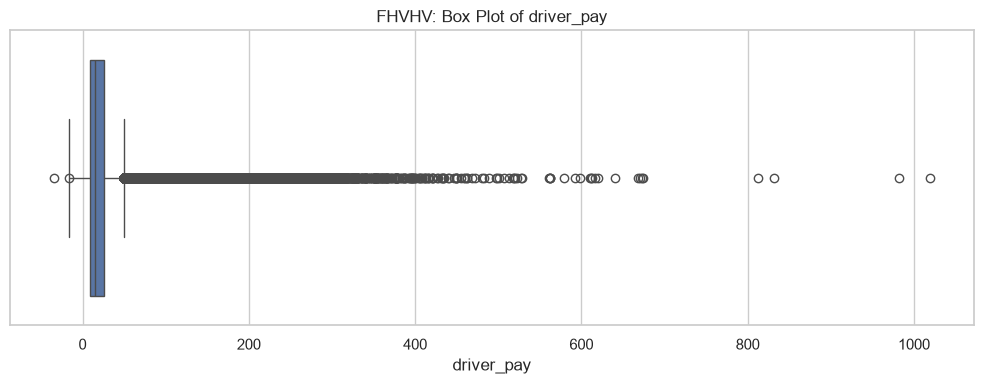

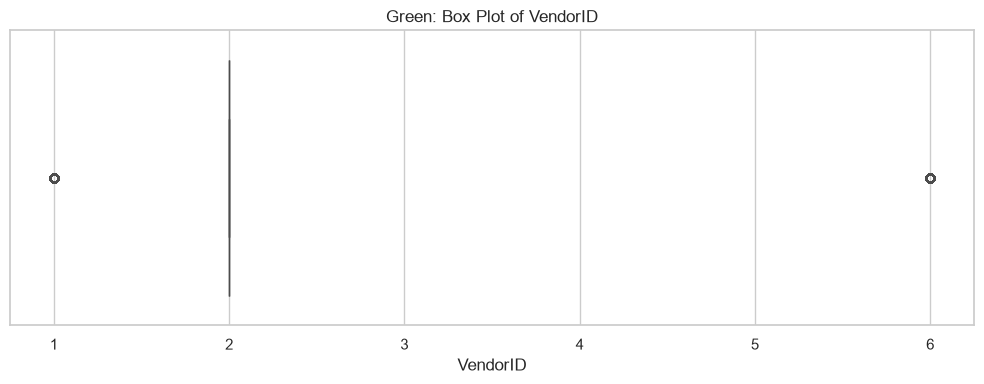

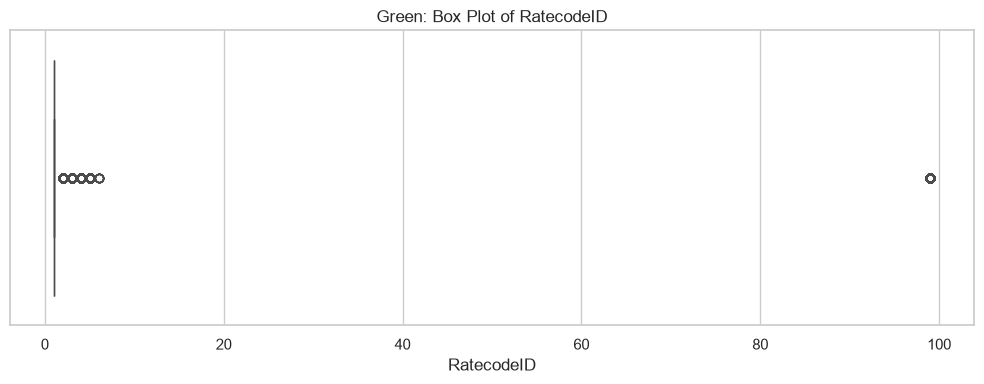

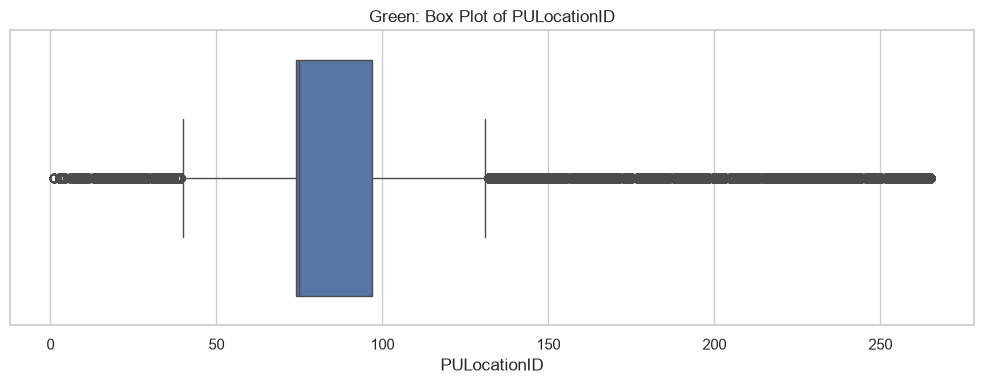

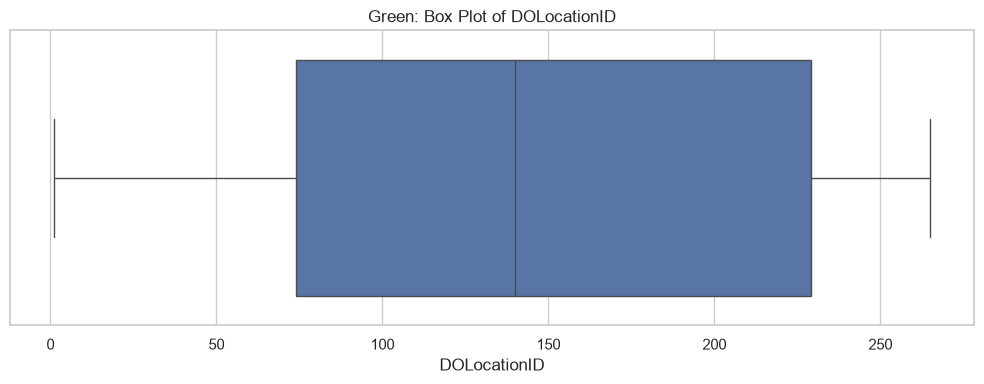

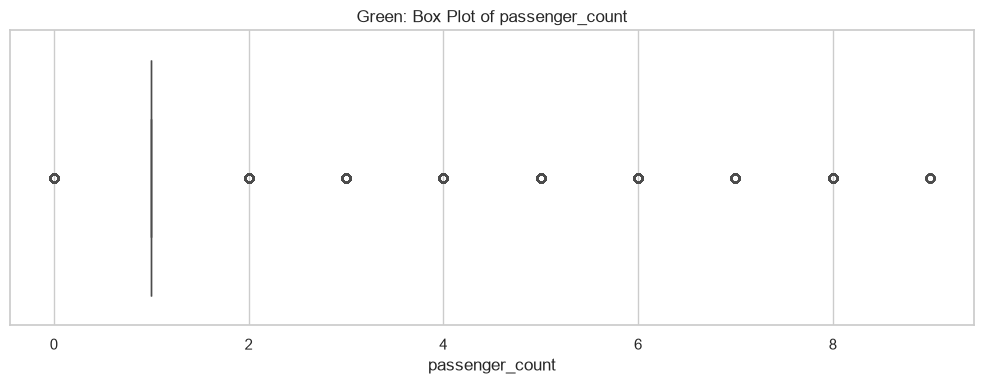

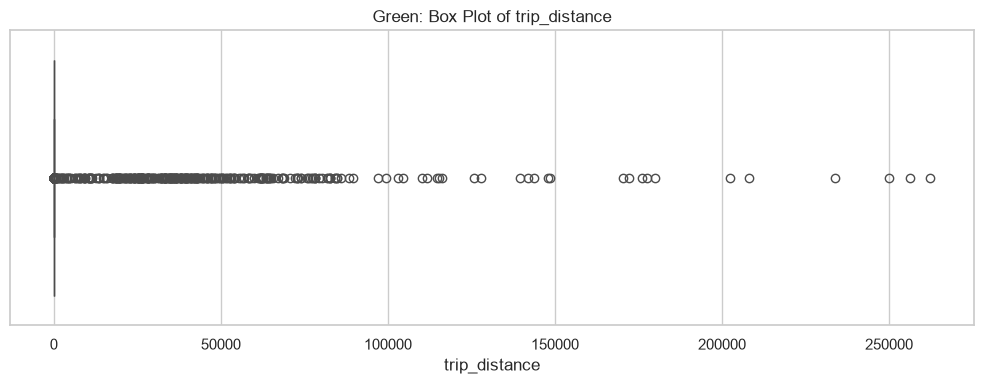

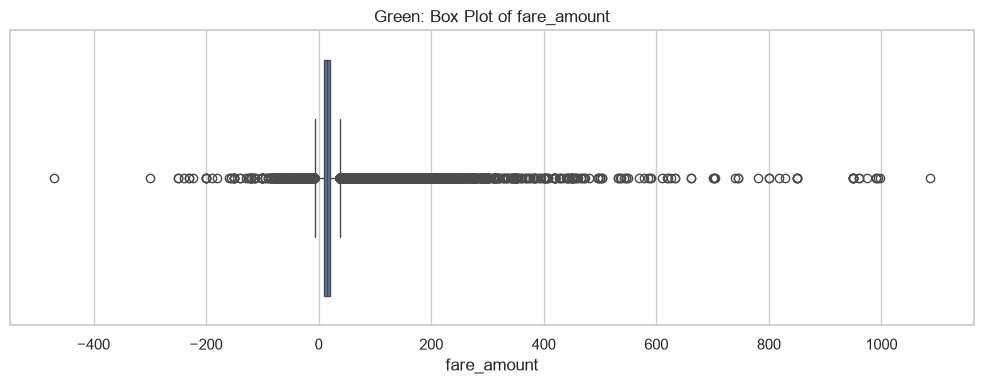

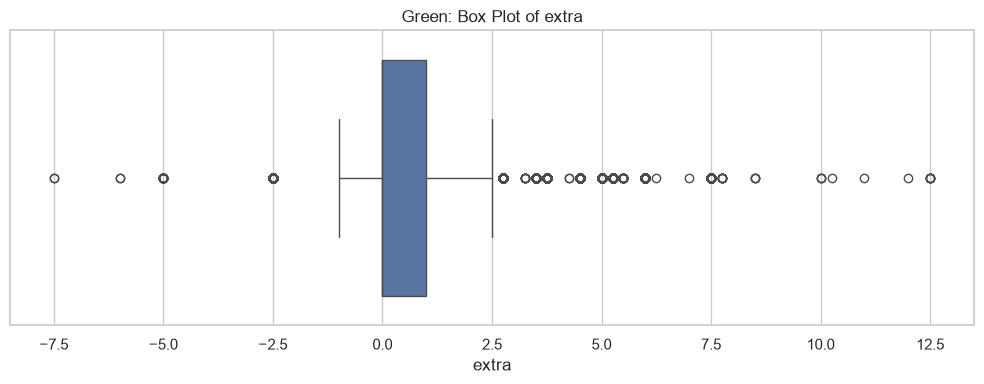

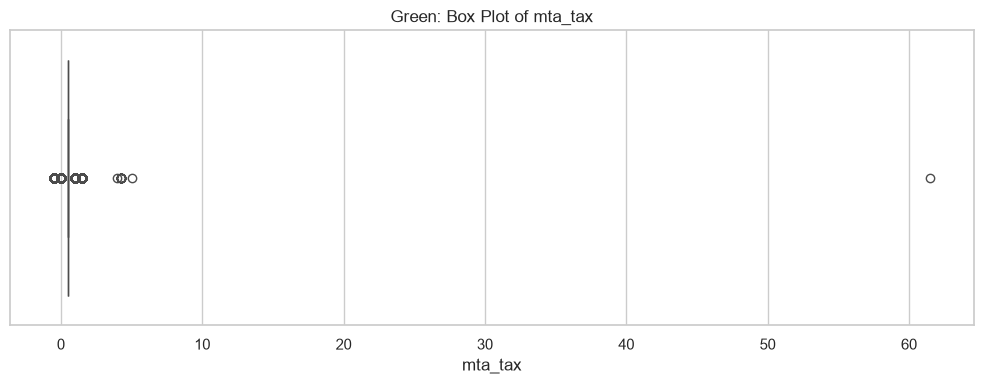

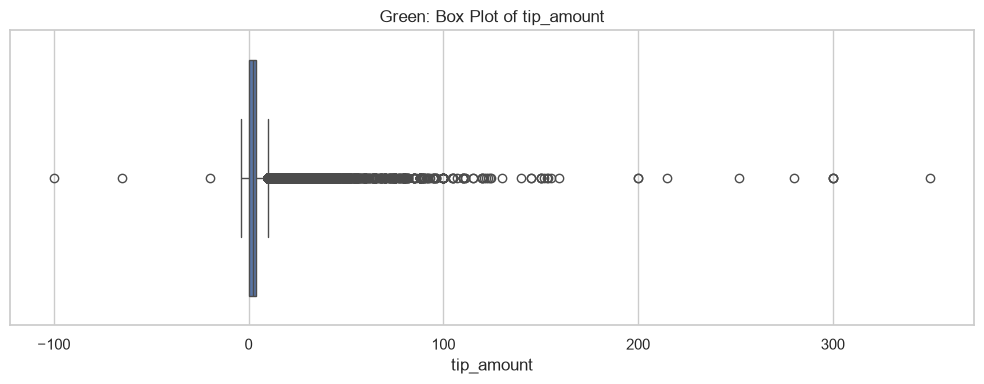

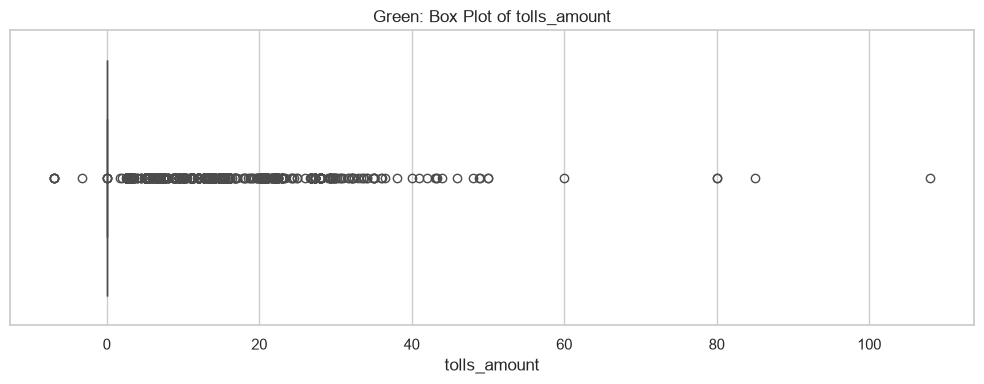

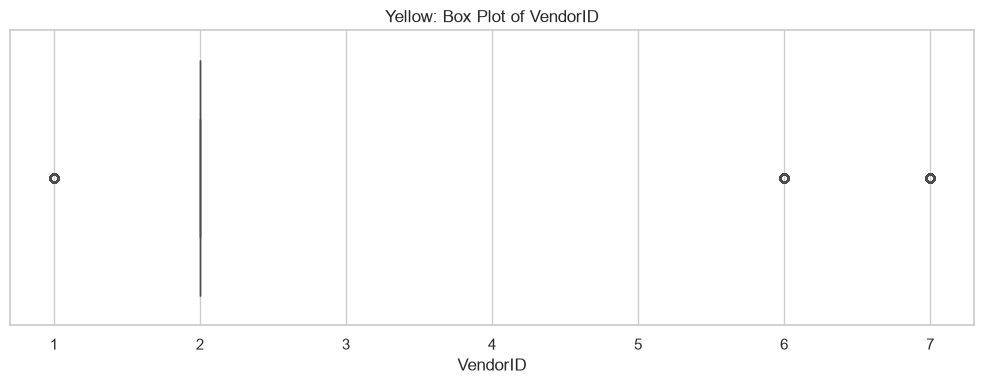

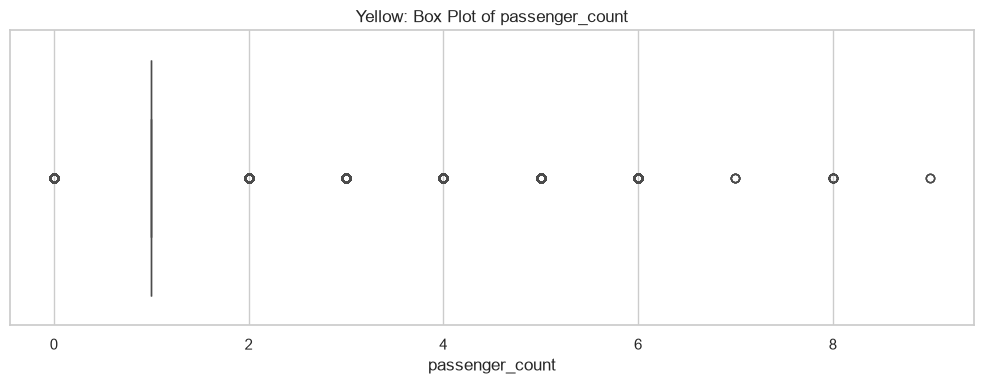

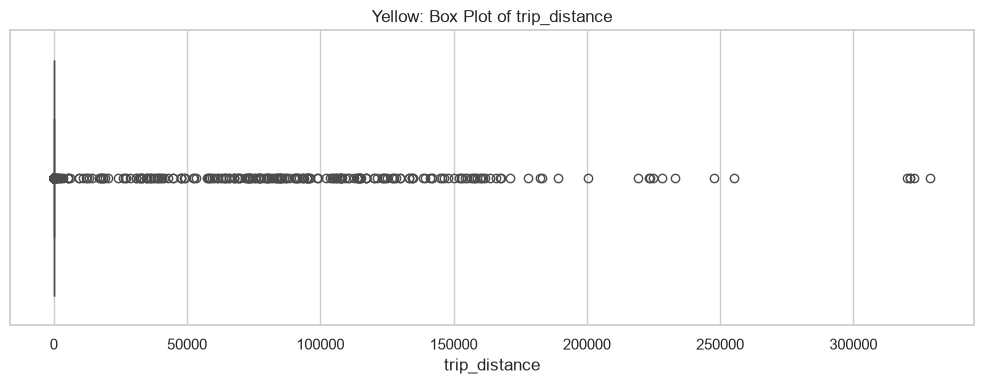

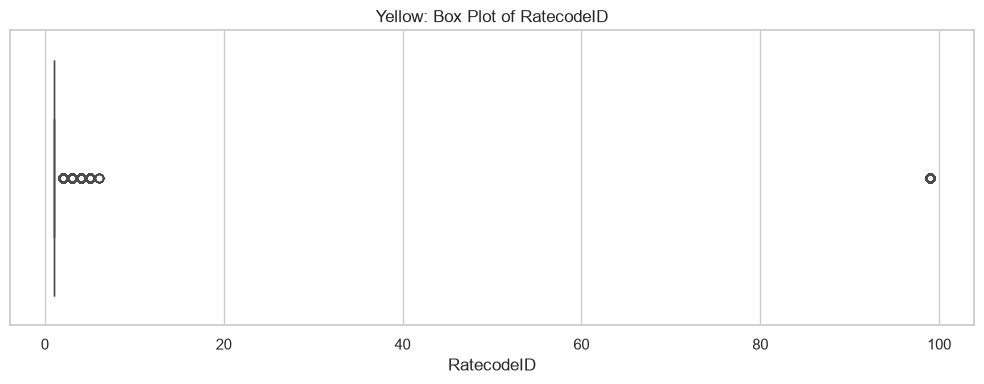

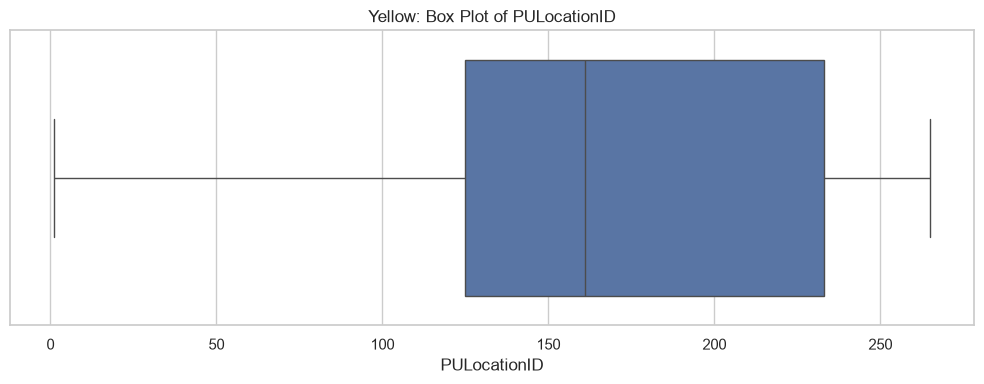

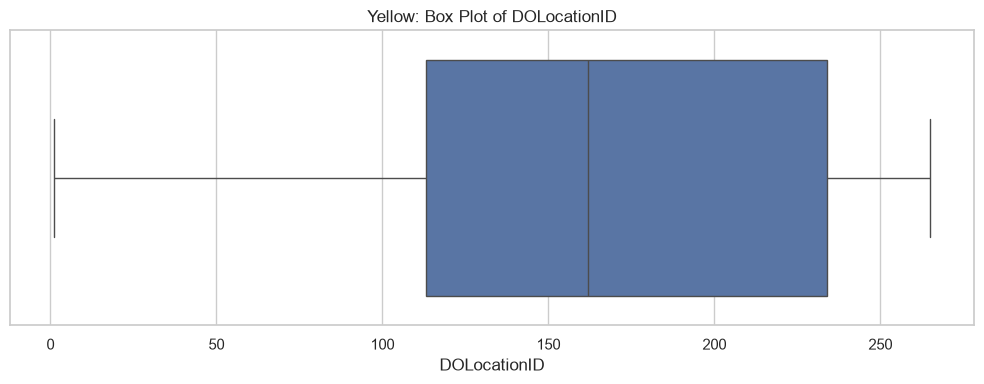

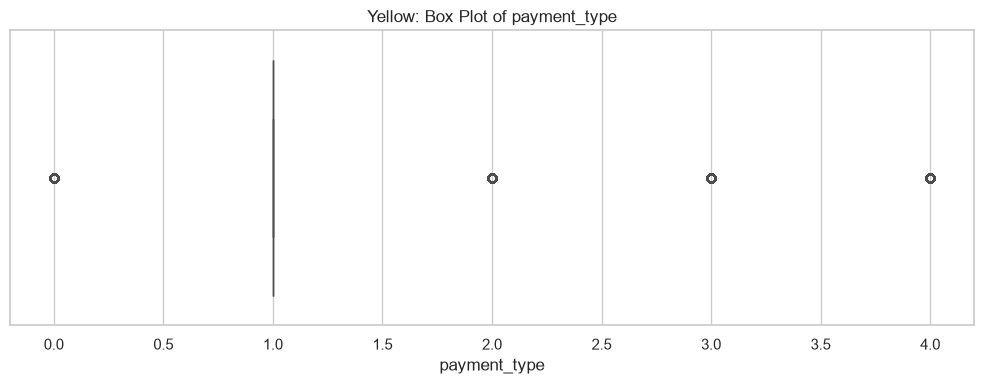

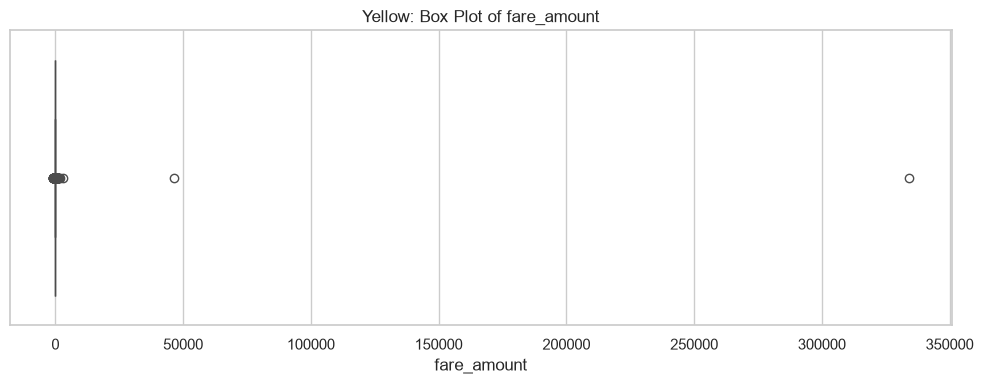

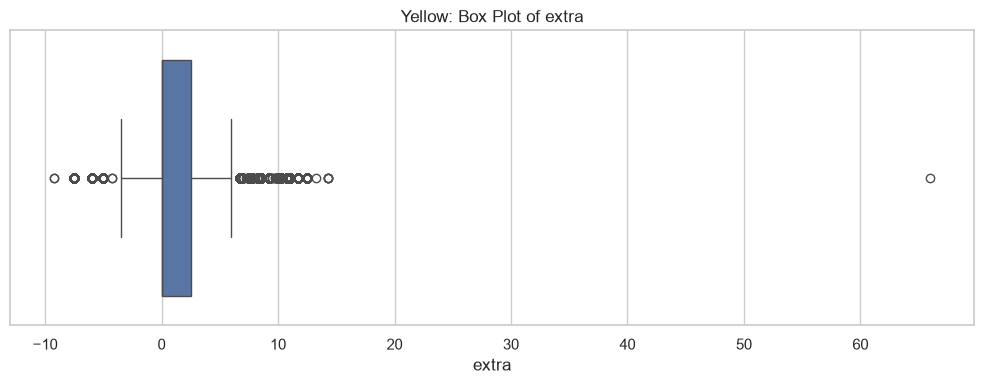

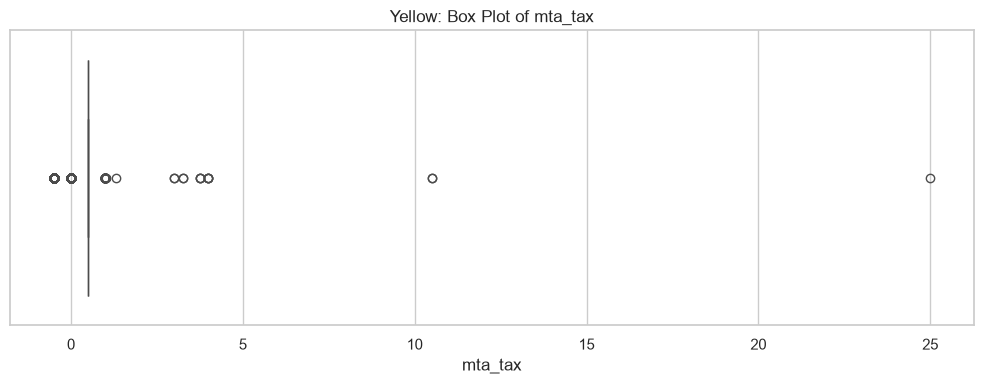

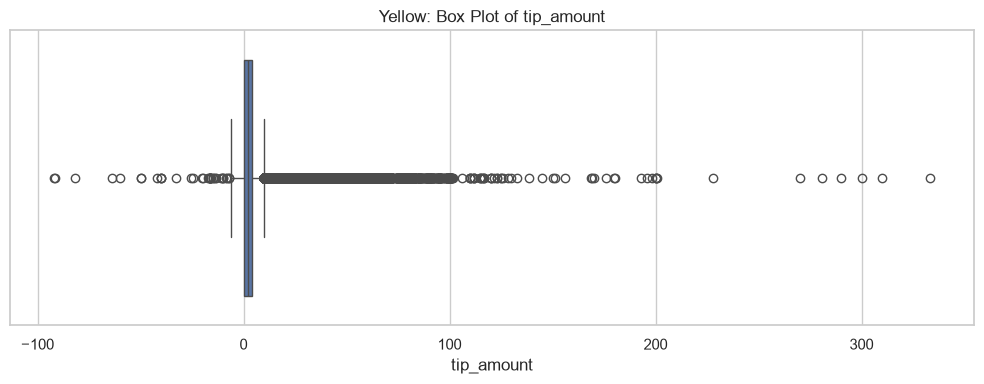

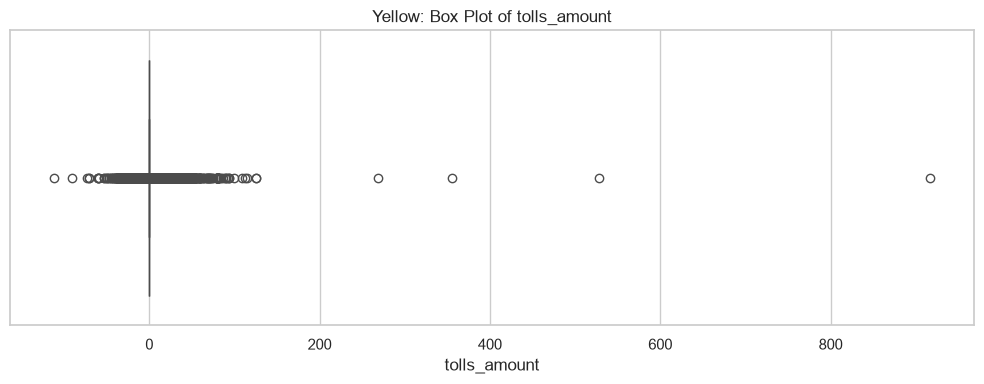

In [15]:
for name, df in samples.items():
    nums = numeric_columns(df)[:12]
    for col in nums:
        series = df[col].dropna()
        if series.empty:
            continue
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=series)
        plt.title(f"{name}: Box Plot of {col}")
        plt.tight_layout()
        plt.show()

## 9. Outlier Analysis — IQR Method

In [16]:
outlier_summary = []

for name, df in samples.items():
    for col in numeric_columns(df):
        s = df[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            count = 0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            count = ((s < lower) | (s > upper)).sum()
        outlier_summary.append({
            "dataset": name,
            "column": col,
            "outlier_count": int(count),
            "outlier_percent": float(count / len(s) * 100)
        })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("outlier_percent", ascending=False)
display(outlier_summary.head(30))

,dataset,column,outlier_count,outlier_percent
17,Green,PULocationID,250854,23.492404
34,Yellow,trip_distance,750185,11.813937
45,Yellow,total_amount,688071,10.835764
20,Green,trip_distance,102317,9.581957
21,Green,fare_amount,87864,8.228438
39,Yellow,fare_amount,512380,8.068976
4,FHVHV,trip_miles,332856,7.564909
8,FHVHV,bcf,329985,7.499659
6,FHVHV,base_passenger_fare,320102,7.275045
27,Green,total_amount,76116,7.128241


## 10. Bivariate Analysis

In [17]:
def find_col(df, candidates):
    lower = {c.lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower:
            return lower[candidate.lower()]
    return None

for name, df in samples.items():
    distance = find_col(df, ["trip_distance", "trip_miles"])
    fare = find_col(df, ["fare_amount", "base_passenger_fare"])
    duration = find_col(df, ["trip_duration", "trip_time", "duration"])

    print(f"{name}: distance={distance}, fare={fare}, duration={duration}")

FHV: distance=None, fare=None, duration=None
FHVHV: distance=trip_miles, fare=base_passenger_fare, duration=trip_time
Green: distance=trip_distance, fare=fare_amount, duration=None
Yellow: distance=trip_distance, fare=fare_amount, duration=None


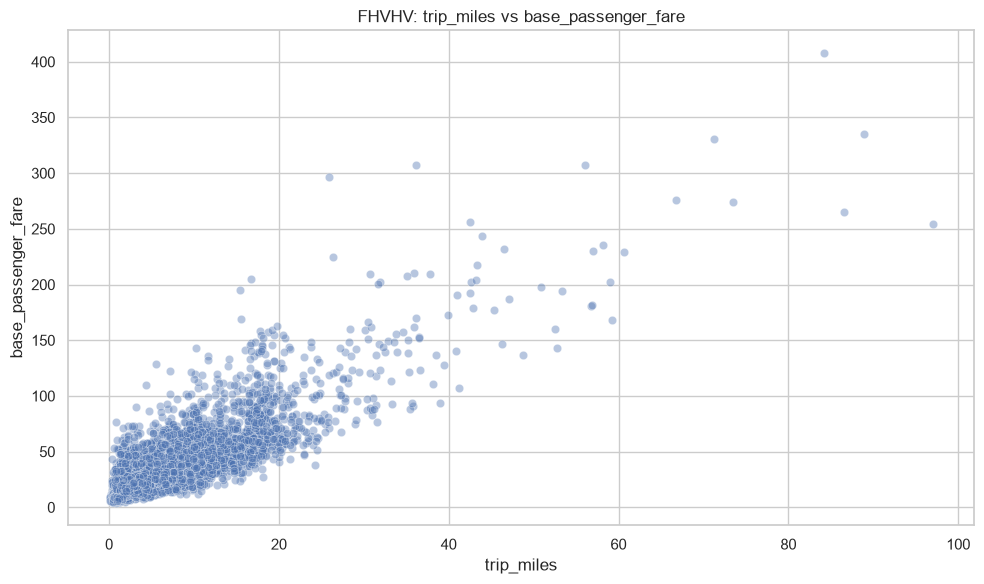

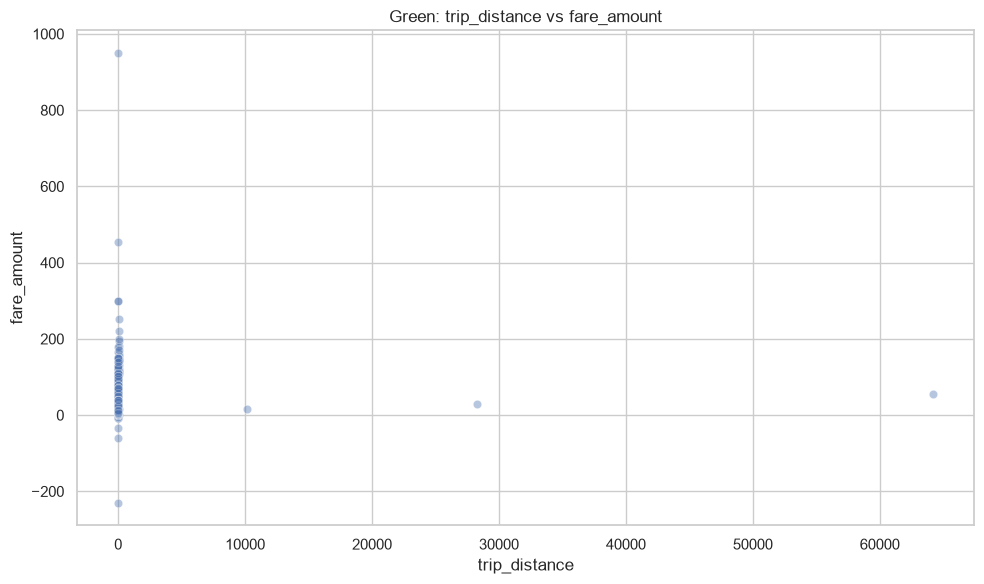

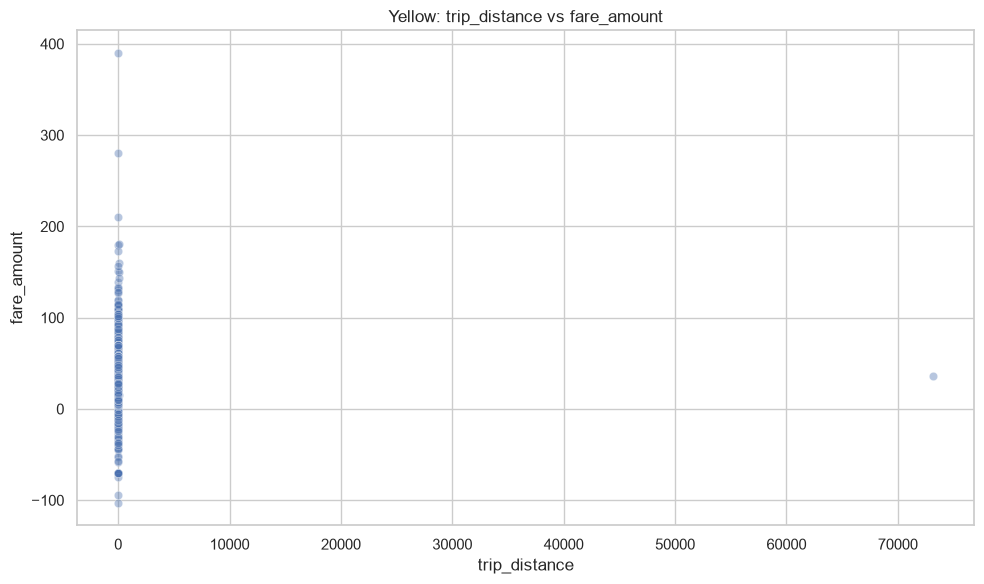

In [18]:
for name, df in samples.items():
    distance = find_col(df, ["trip_distance", "trip_miles"])
    fare = find_col(df, ["fare_amount", "base_passenger_fare"])

    if distance and fare:
        plot_df = df[[distance, fare]].dropna()
        # Prevent a handful of extreme observations from compressing the plot.
        if len(plot_df) > 10_000:
            plot_df = plot_df.sample(10_000, random_state=RANDOM_STATE)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=plot_df, x=distance, y=fare, alpha=0.4)
        plt.title(f"{name}: {distance} vs {fare}")
        plt.tight_layout()
        plt.show()

## 11. Multivariate Analysis — Correlation Heatmaps

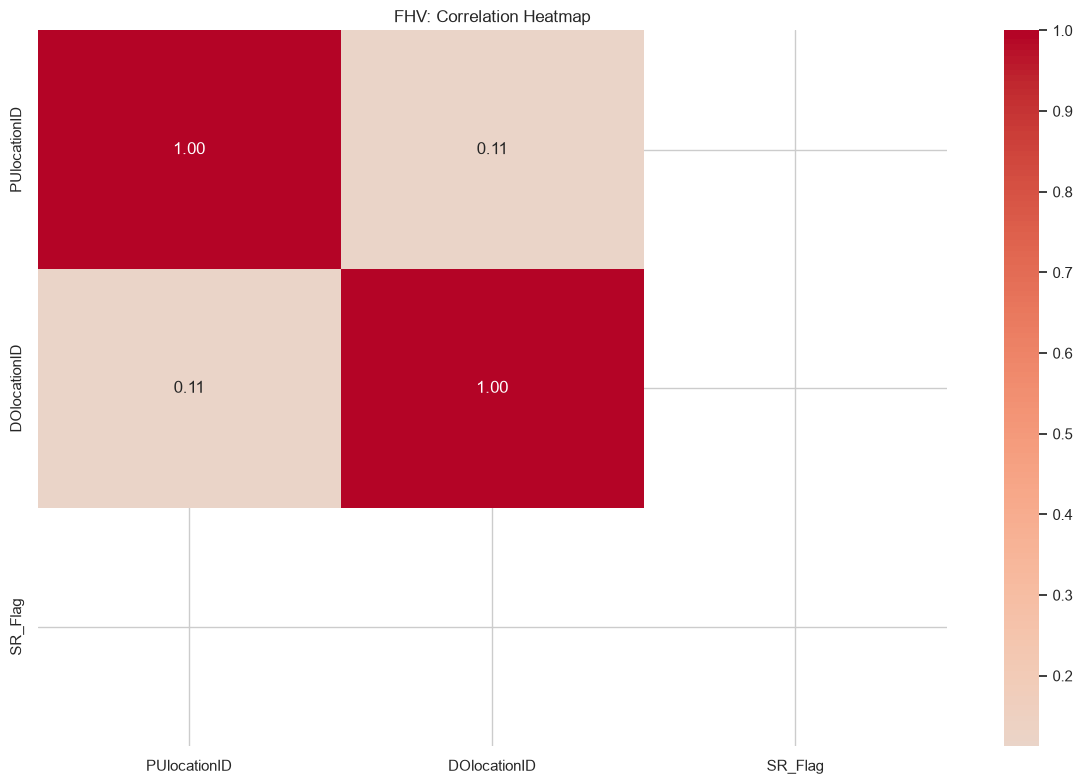

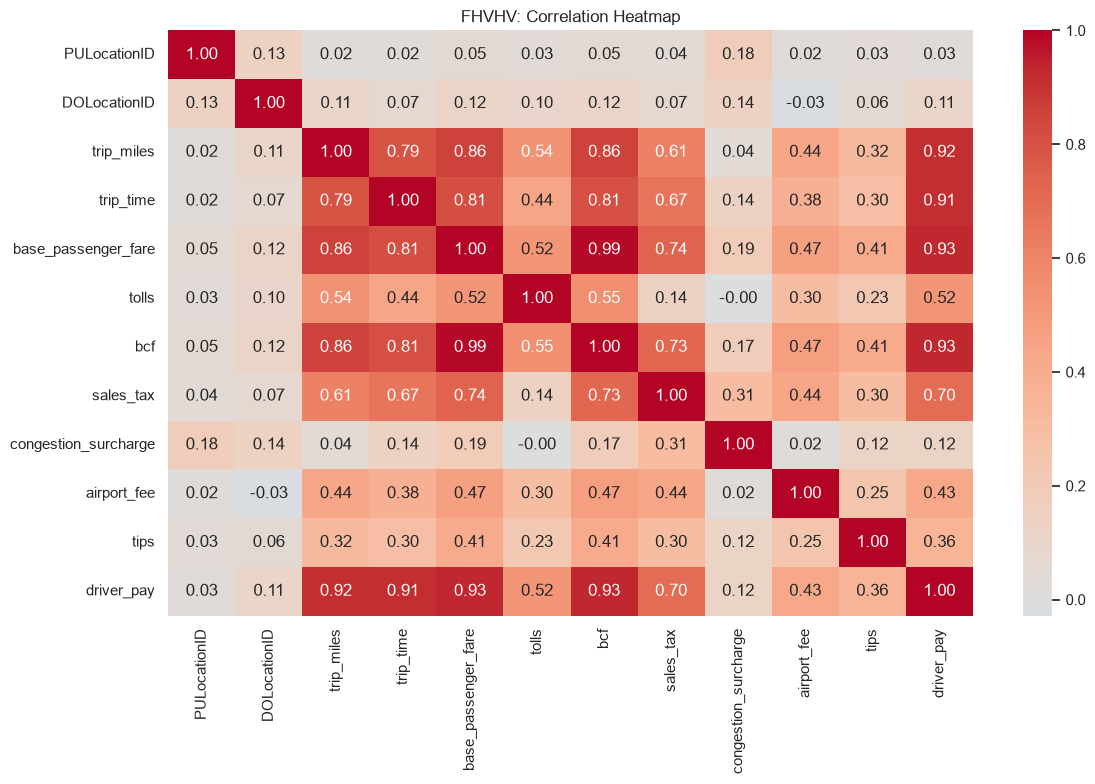

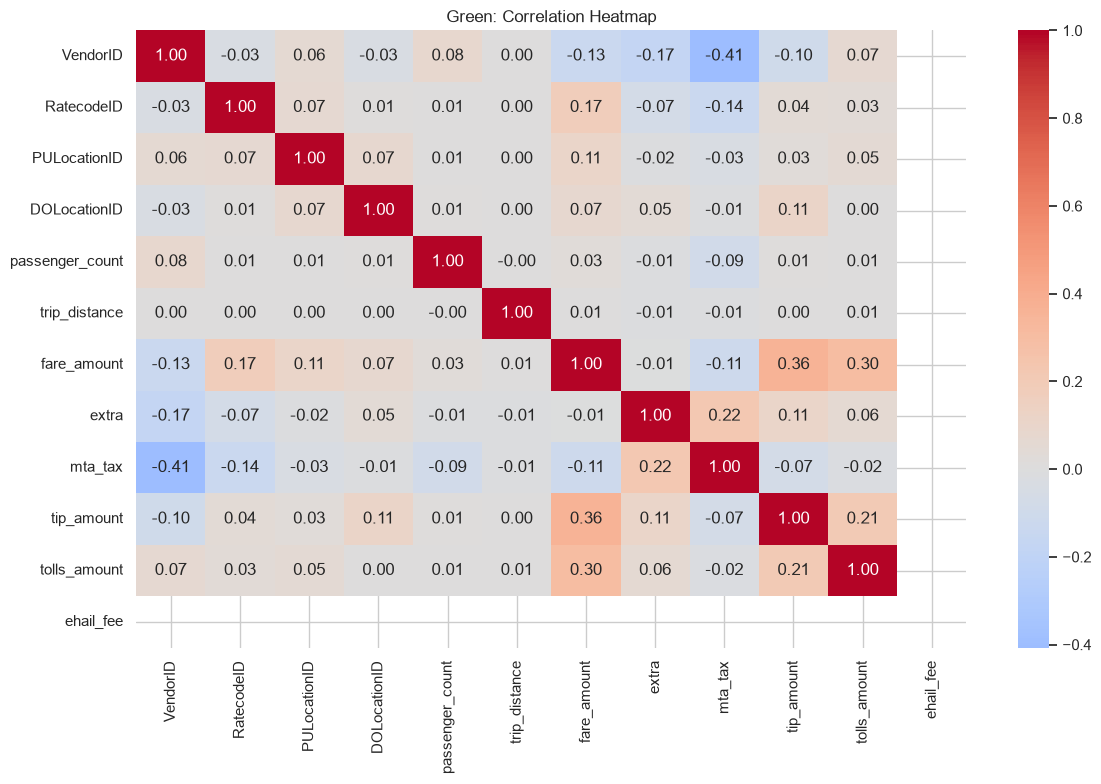

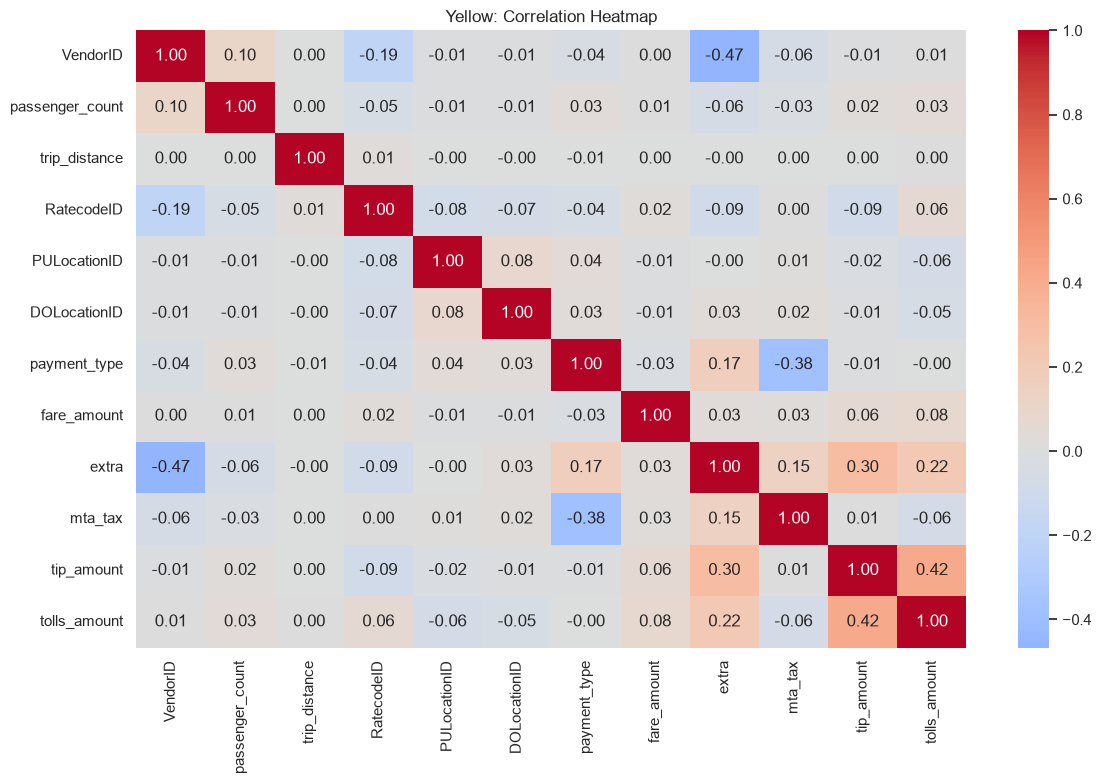

In [19]:
for name, df in samples.items():
    nums = numeric_columns(df)
    if len(nums) < 2:
        continue
    # Select the first 12 numeric columns to keep the heatmap readable.
    selected = nums[:12]
    corr = df[selected].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"{name}: Correlation Heatmap")
    plt.tight_layout()
    plt.show()

## 12. Pair Plot — Selected Variables

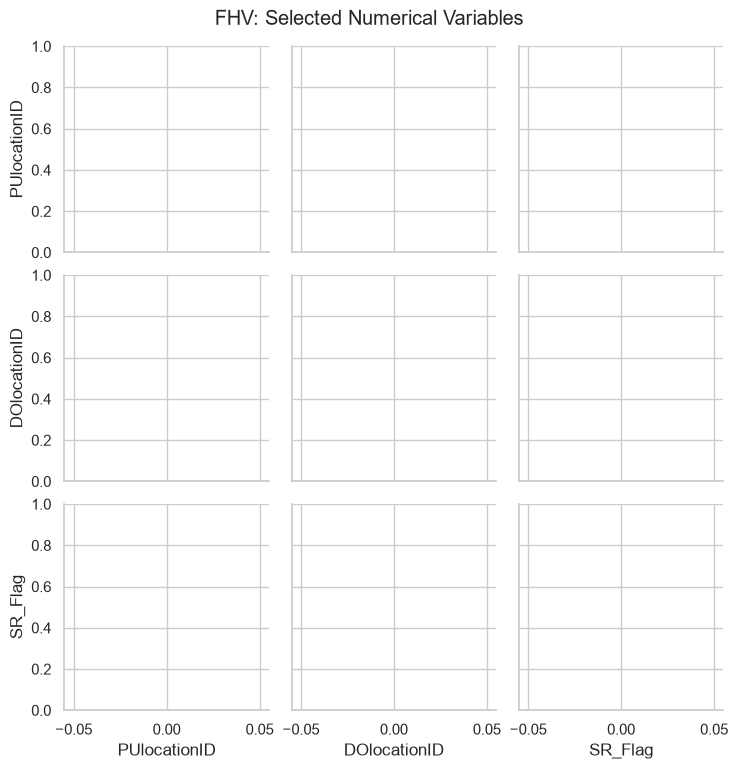

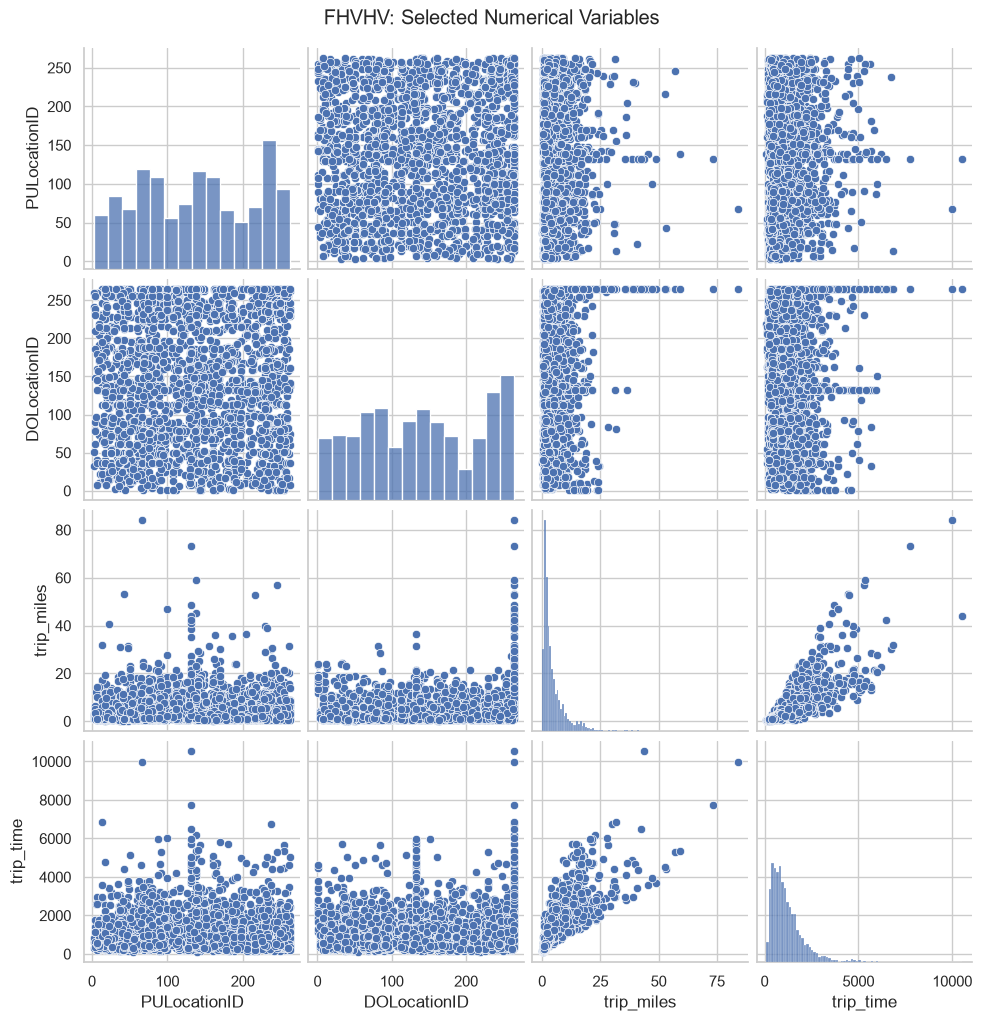

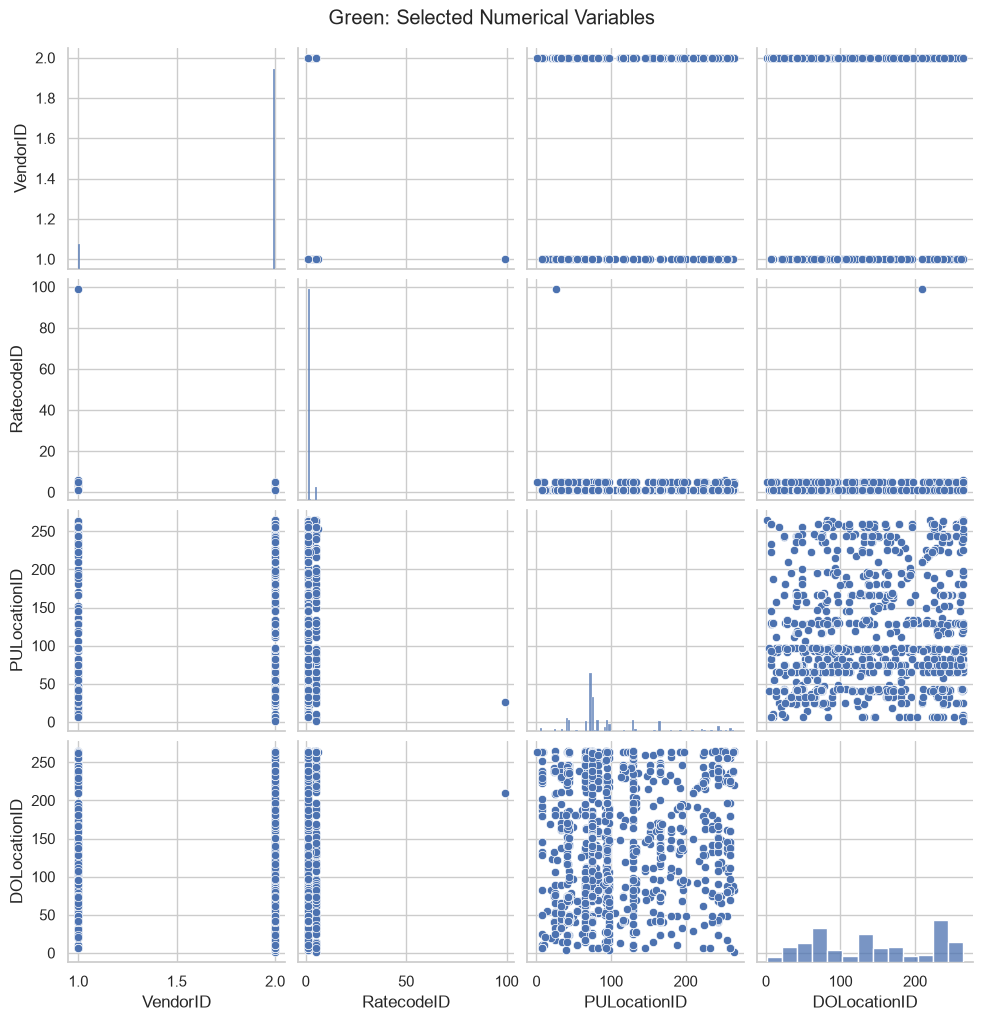

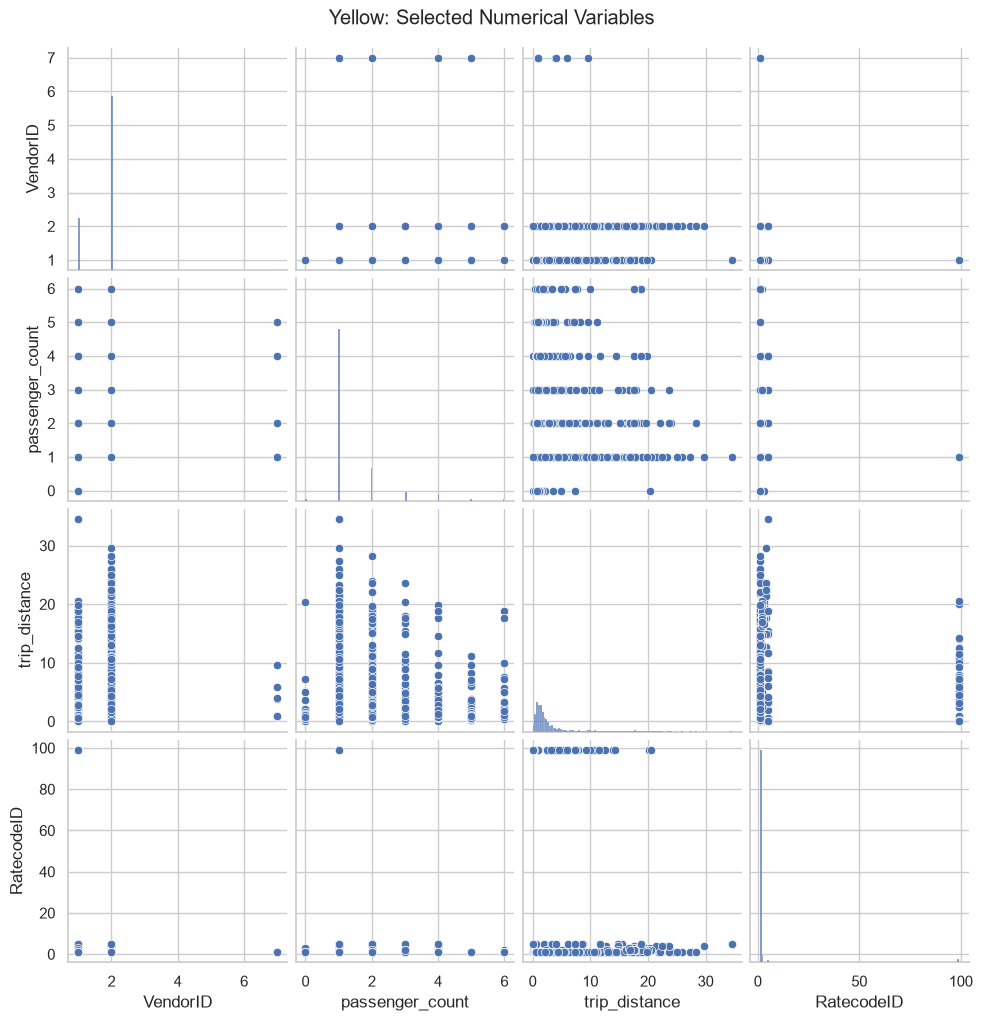

In [20]:
for name, df in samples.items():
    nums = numeric_columns(df)
    selected = nums[:4]
    if len(selected) >= 2:
        pair_df = df[selected].dropna()
        if len(pair_df) > 3_000:
            pair_df = pair_df.sample(3_000, random_state=RANDOM_STATE)
        sns.pairplot(pair_df)
        plt.suptitle(f"{name}: Selected Numerical Variables", y=1.02)
        plt.show()

## 13. Taxi-Specific Time Analysis

In [21]:
def datetime_columns(df):
    result = []
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            result.append(col)
        elif df[col].dtype == "object" and any(k in col.lower() for k in ["datetime", "date", "time"]):
            converted = pd.to_datetime(df[col], errors="coerce")
            if converted.notna().mean() > 0.5:
                result.append(col)
    return result

for name, df in samples.items():
    print(name, "datetime-like columns:", datetime_columns(df))

FHV datetime-like columns: ['pickup_datetime', 'dropOff_datetime']
FHVHV datetime-like columns: ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime']
Green datetime-like columns: ['lpep_pickup_datetime', 'lpep_dropoff_datetime']
Yellow datetime-like columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime']


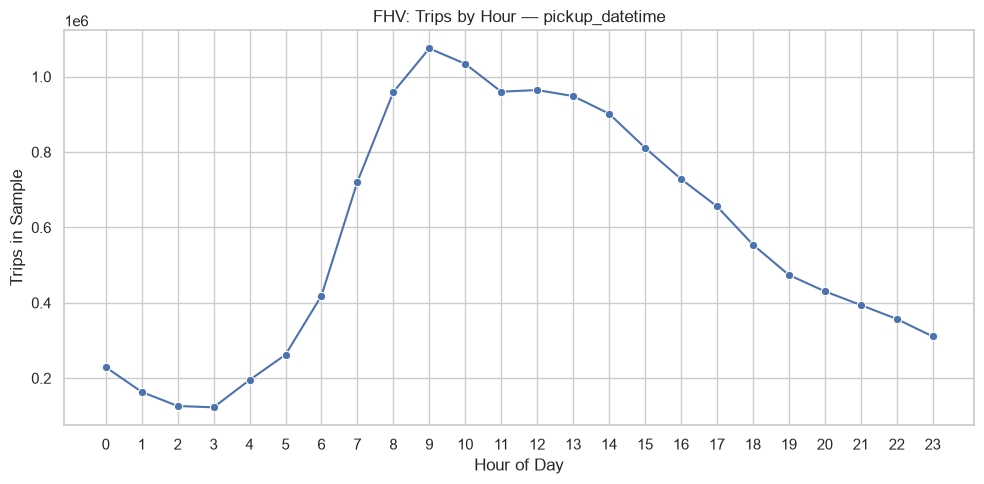

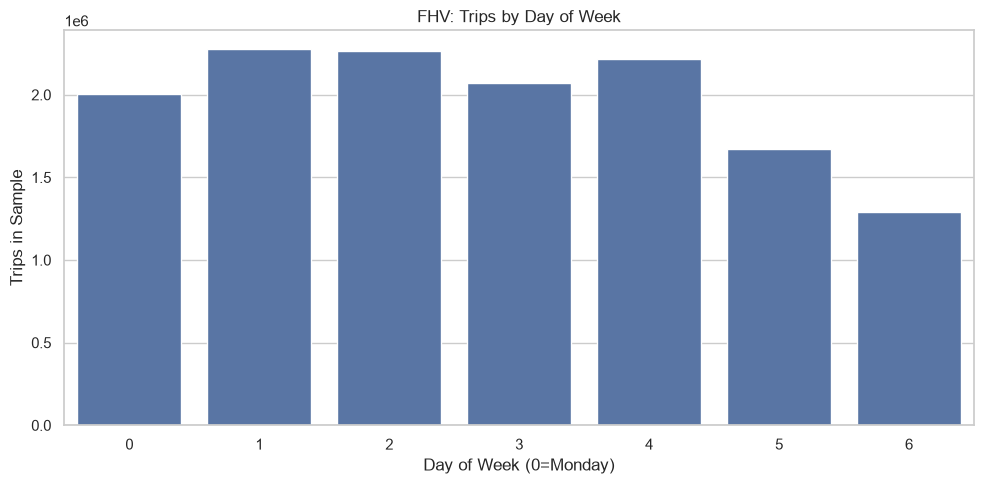

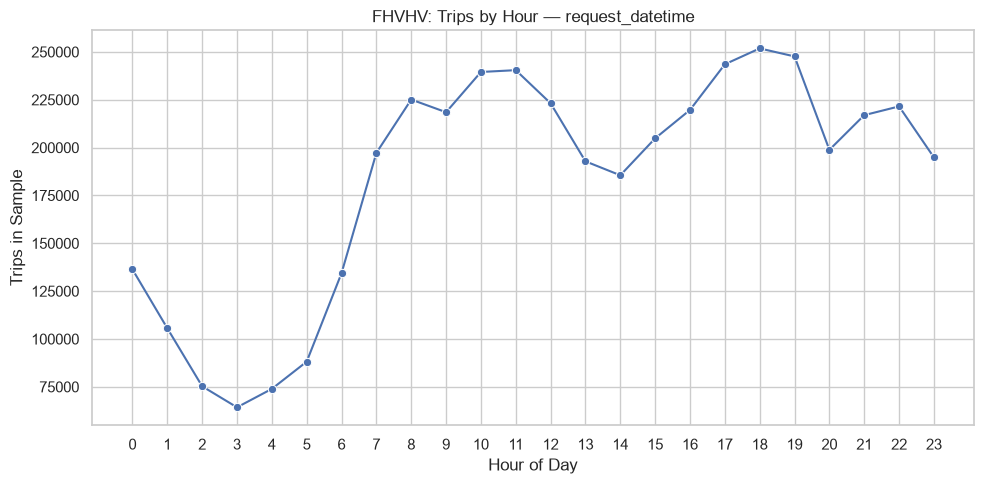

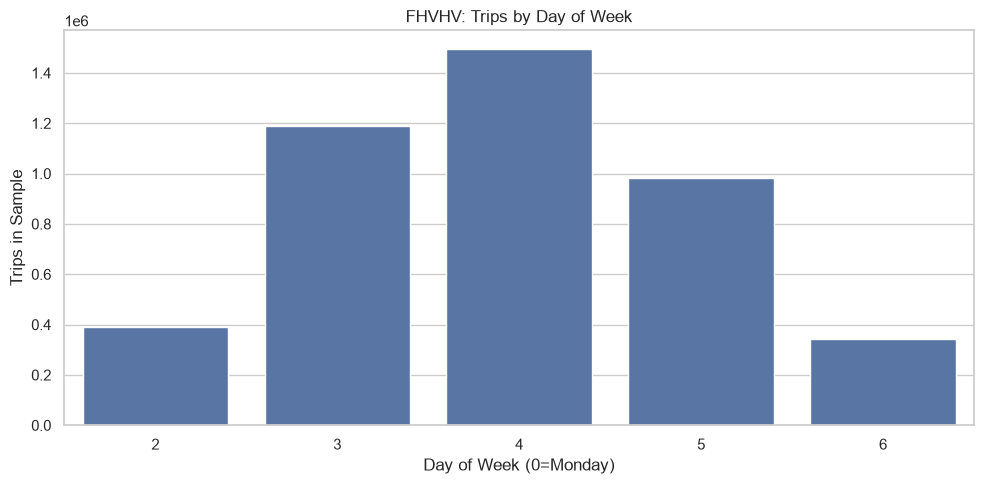

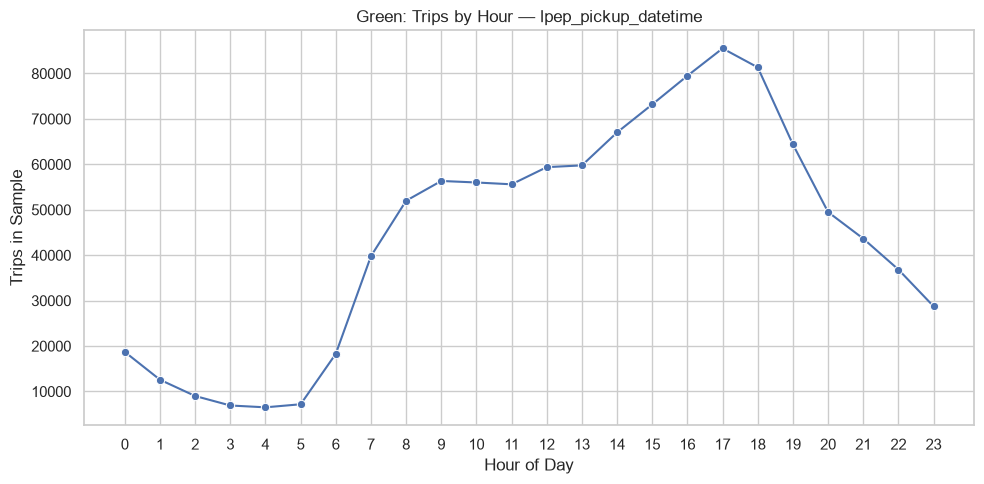

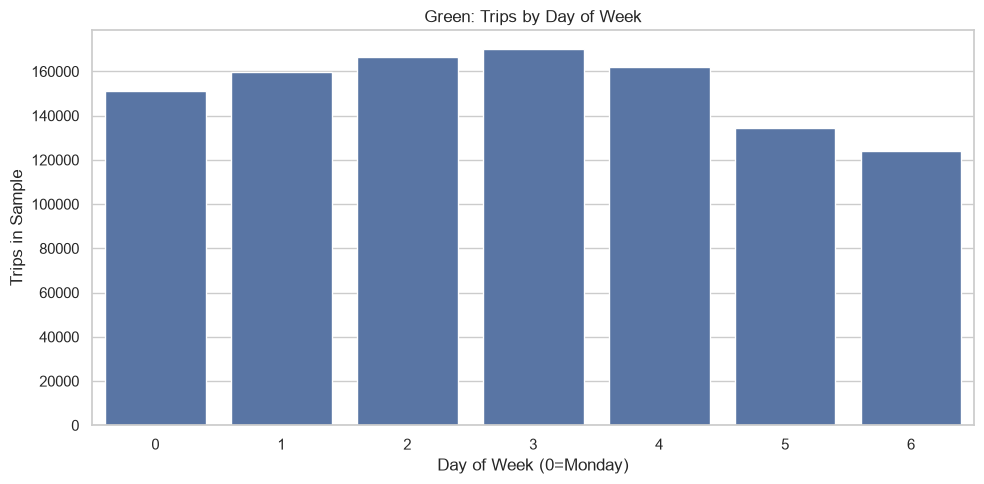

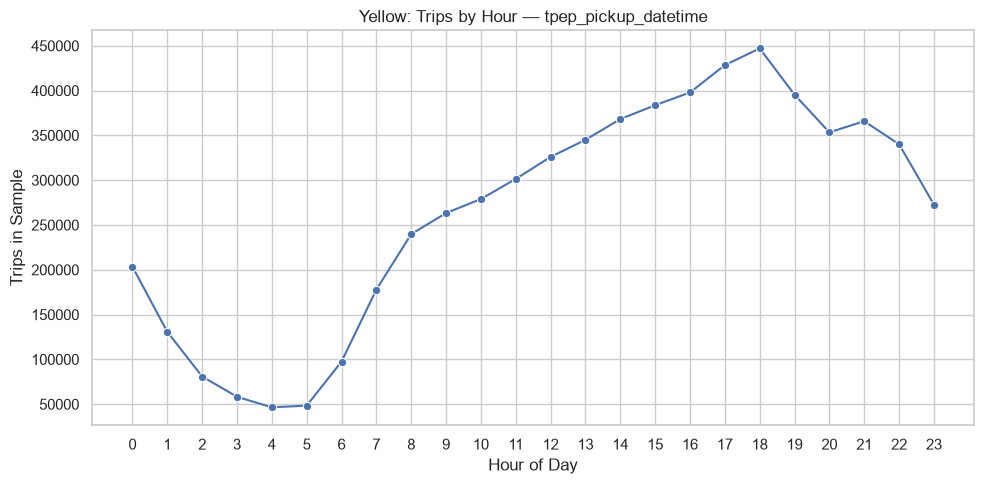

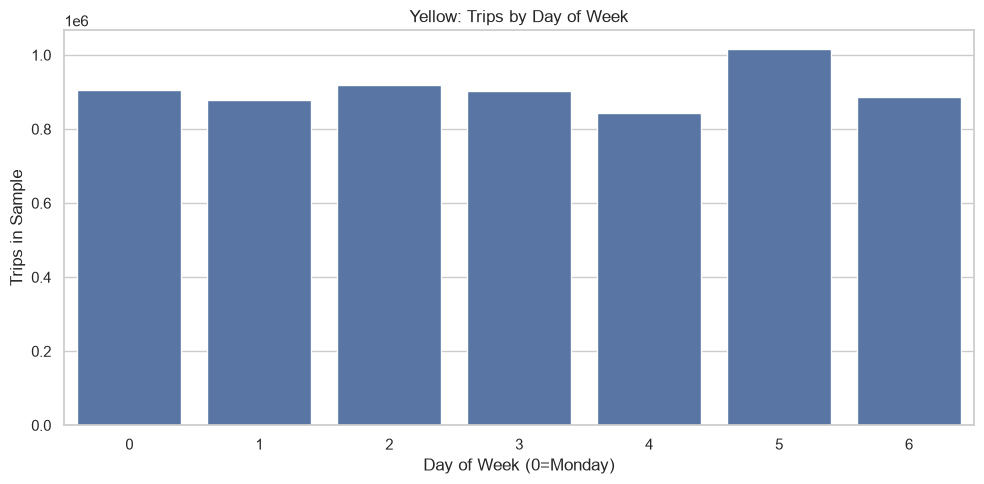

In [22]:
for name, df in samples.items():
    dt_cols = datetime_columns(df)
    if not dt_cols:
        continue

    col = dt_cols[0]
    dt = pd.to_datetime(df[col], errors="coerce")
    time_df = pd.DataFrame({"datetime": dt}).dropna()
    if time_df.empty:
        continue

    hourly = time_df["datetime"].dt.hour.value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=hourly.index, y=hourly.values, marker="o")
    plt.title(f"{name}: Trips by Hour — {col}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Trips in Sample")
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()

    weekday = time_df["datetime"].dt.dayofweek.value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    sns.barplot(x=weekday.index, y=weekday.values)
    plt.title(f"{name}: Trips by Day of Week")
    plt.xlabel("Day of Week (0=Monday)")
    plt.ylabel("Trips in Sample")
    plt.tight_layout()
    plt.show()

## 14. Data Quality Checks

In [23]:
quality_flags = []

for name, df in samples.items():
    checks = {
        "negative_trip_distance": find_col(df, ["trip_distance", "trip_miles"]),
        "negative_fare": find_col(df, ["fare_amount", "base_passenger_fare"]),
        "negative_total": find_col(df, ["total_amount"]),
        "negative_passenger_count": find_col(df, ["passenger_count"]),
    }

    for check, col in checks.items():
        if col is not None:
            count = (pd.to_numeric(df[col], errors="coerce") < 0).sum()
            quality_flags.append({"dataset": name, "check": check, "count": int(count)})

quality_flags = pd.DataFrame(quality_flags)
display(quality_flags)

,dataset,check,count
0,FHVHV,negative_trip_distance,0
1,FHVHV,negative_fare,180
2,Green,negative_trip_distance,0
3,Green,negative_fare,3236
4,Green,negative_total,3294
5,Green,negative_passenger_count,0
6,Yellow,negative_trip_distance,0
7,Yellow,negative_fare,114834
8,Yellow,negative_total,97023
9,Yellow,negative_passenger_count,0


## 15. Cross-Dataset Comparison

In [24]:
comparison = pd.DataFrame([
    {
        "dataset": name,
        "sample_rows": len(df),
        "columns": df.shape[1],
        "numeric_columns": len(numeric_columns(df)),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    }
    for name, df in samples.items()
])

display(comparison)

,dataset,sample_rows,columns,numeric_columns,missing_cells,duplicate_rows
0,FHV,13800000,7,3,27375520,16476
1,FHVHV,4400000,25,13,1886449,0
2,Green,1067809,21,18,1923066,0
3,Yellow,6350000,20,17,11354027,0


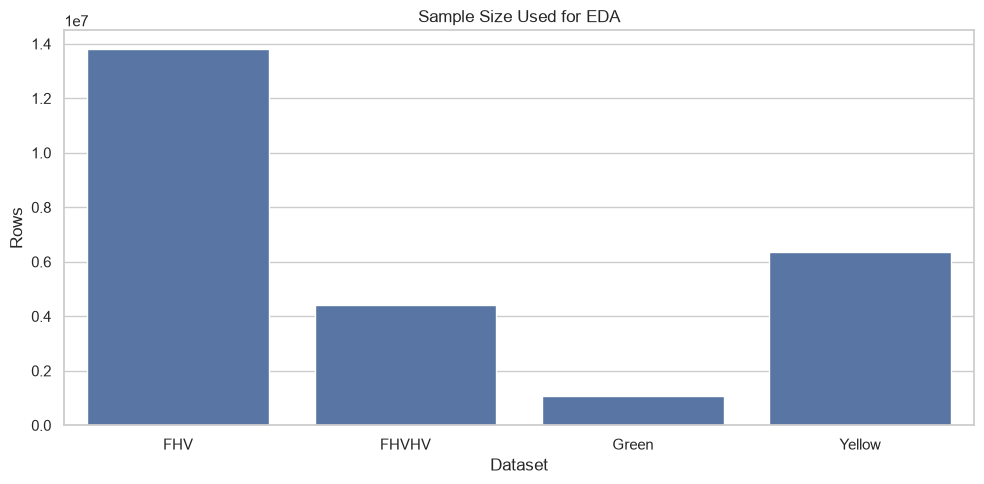

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="dataset", y="sample_rows")
plt.title("Sample Size Used for EDA")
plt.xlabel("Dataset")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## 16. Final Summary

In [26]:
print("EDA completed.")
print(f"Sample size per dataset target: {SAMPLE_ROWS_PER_DATASET:,}")
print("Datasets analysed:", ", ".join(samples.keys()))

EDA completed.
Sample size per dataset target: 250,000
Datasets analysed: FHV, FHVHV, Green, Yellow
